# Bayesian Optimisation: ERK CNR-AUC (v15 — free shape + Level-3 cell adjustment)

v15 keeps v14's **free temporal shape** (3 polynomial coefficients + pulse
interval, fixed 4 s budget) but changes **how the per-FOV objective is built**
from the single cells.

| Notebook | Objective | Cell aggregation | Covariates in GP |
|---|---|---|---|
| `...v14_free_pattern` | `auc_norm` | **median**, divide-by-baseline | n_cells, optortk_expression, baseline_cnr |
| `...v15_free_pattern_level3` (this) | **`auc_adj`** | **mean** of cell-level **adjusted** AUC | **n_cells only** |

**What changed and why.**

1. **Mean, not median (breadth × depth).**  v14 took the per-FOV *median* of the
   per-cell normalised AUC, which hides the responder/non-responder split.  v15
   takes the **mean over all valid cells** of the adjusted absolute AUC, with
   non-responders clipped to 0 — so a pattern only scores high if *many* cells
   respond *well*.  The single objective already balances breadth and depth, so
   we do **not** need a second GP (a deliberate scope choice for this first
   Level-3 notebook).

2. **Level-3 cell-level covariate adjustment (ANCOVA), replacing the ratio.**
   v13/v14 removed the baseline-magnitude confound by *dividing* per-cell AUC by
   the cell's baseline — a ratio that is heteroscedastic and over-corrects.  v15
   instead regresses per-cell **absolute** AUC on per-cell **baseline CNR** and
   **log optoRTK expression**, pooled across every cell collected so far, and
   uses the **residual** (re-anchored to the global covariate means so the level
   is preserved).  Because both covariates are assigned to FOVs independently of
   the light pattern, regressing them out removes nuisance variance *without*
   eating the pattern effect.

3. **Covariates leave the GP.**  Since baseline and expression are now handled at
   the cell level, they are **dropped from the GP covariates** — only `n_cells`
   remains.  The GP shrinks from 4 control + 3 covariates (7-D) to 4 control + 1
   covariate (5-D), which is far healthier for ~234 FOV observations.  An
   *irrelevant* covariate self-disables: its regression slope comes out ≈ 0 and
   the adjustment becomes the identity, costing nothing (unlike a useless GP
   dimension).  Relevance is read from the **regression slope + R²**
   (`self._nuisance_history`), not from an ARD lengthscale.

**Recorded as diagnostics (not optimised):** v14 median `auc_norm`, absolute
`auc_above_baseline`, `frac_responders` (fraction of cells with peak fold-change
> `RESPONDER_PEAK_FOLD`), per-FOV `auc_adj_se`, and the per-phase nuisance fit.

> **Caveat (same as v13/v14).**  AUC rewards *sustained* ERK, not oscillation.
> v15 is a response-*magnitude* / shape experiment.
>
> **Known simplification.**  Each FOV's `auc_adj` is computed once, with the
> nuisance slopes available at that phase; slopes refine as cells accumulate, so
> early-phase objectives use slightly coarser slopes.  Slopes stabilise within a
> phase or two (hundreds of cells), so the effect on ranking is minor.

In [1]:
import os
import time
import logging
import importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Suppress JAX/XLA debug messages
os.environ["JAX_LOG_COMPILES"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import jax

jax.config.update("jax_log_compiles", False)
for _name in list(logging.Logger.manager.loggerDict):
    if "jax" in _name or "absl" in _name:
        logging.getLogger(_name).setLevel(logging.WARNING)

# ---------------------------------------------------------------------------
# gpax/numpyro compatibility shim
# ---------------------------------------------------------------------------
# numpyro >= 0.20 removed haiku support from numpyro.contrib.module, but
# gpax 0.1.9 eagerly imports viDKL via gpax/models/__init__.py, which tries
# `from numpyro.contrib.module import random_haiku_module, haiku_module`.
# We don't use viDKL (only ExactGP, viGP, viSparseGP), so we install stubs
# that raise only if viDKL is actually called. This MUST run before any
# `import gpax` (including the lazy ones inside the BO agent classes).
import numpyro.contrib.module as _ncm


def _haiku_unavailable(*_args, **_kwargs):
    raise NotImplementedError(
        "haiku support was removed from numpyro >= 0.20. "
        "viDKL is not available. Use ExactGP, viGP, or viSparseGP."
    )


if not hasattr(_ncm, "random_haiku_module"):
    _ncm.random_haiku_module = _haiku_unavailable
if not hasattr(_ncm, "haiku_module"):
    _ncm.haiku_module = _haiku_unavailable
# ---------------------------------------------------------------------------

from faro.core.data_structures import (
    PowerChannel,
    SegmentationMethod,
)
from faro.core.controller import Controller
from faro.core.pipeline import ImageProcessingPipeline
from faro.agents.bo_optimization import (
    BO_Parameter,
    BO_Objective,
    BO_Covariate,
)
from faro.agents.bo_oscillation import OscillationBO
import faro.core.utils as utils

## Microscope & pipeline setup

**Microscope:** Jungfrau (no DMD -- full-FOV stimulation).

**Channels:**
- Imaging: miRFP (nuclear marker) + mScarlet3 (ERK-KTR reporter)
- Stimulation: CyanStim (optogenetic activation, power 10)
- Optocheck: mCitrine (verify optoRTK expression, last frame only)

**Pipeline:** CellposeV4 segmentation -> ERK-KTR FE -> Trackpy tracking
-> OptoCheckFE on reference frames. Full-FOV stimulation (no DMD).

In [2]:
from faro.microscope.pertzlab.jungfrau import Jungfrau

mic = Jungfrau()
mic.mmc.setChannelGroup("TTL_ERK")

In [3]:
mic.mmc.setProperty("TIPFSStatus", "State", "On")

In [4]:
import napari
from napari_micromanager import MainWindow

viewer = napari.Viewer()
mm_wdg = MainWindow(viewer)
mm_wdg._mmc = mic.mmc  # point the widget at our CMMCore instance
viewer.window.add_dock_widget(mm_wdg)  # dock Micro-Manager controls in napari
mic.mmc.setProperty("TIPFSStatus", "State", "On")

In [4]:
WELLS = []
START_COL = 2
END_COL = 12
for i, row in enumerate("ABCDEFGH"):
    cols = (
        range(START_COL, END_COL + 1)
        if i % 2 == 0
        else range(END_COL, START_COL - 1, -1)
    )
    WELLS.extend(f"{row}{c}" for c in cols)

In [14]:
len(WELLS)
WELLS = WELLS[::-1]

In [11]:
# --- Experiment parameters ---
TIME_BETWEEN_TIMESTEPS = 60  # seconds (1 frame/min)

# --- Phase layout (frames; 1 frame == 1 minute at TIME_BETWEEN_TIMESTEPS=60) ---
N_FRAMES_BASELINE = 10
N_FRAMES_STIM = 60
N_FRAMES_RECOVERY = 20

# Derived (don't edit -- adjust the three above instead).
N_FRAMES = N_FRAMES_BASELINE + N_FRAMES_STIM + N_FRAMES_RECOVERY  # 90
FIRST_FRAME_STIM = N_FRAMES_BASELINE  # 10
LAST_FRAME_STIM = FIRST_FRAME_STIM + N_FRAMES_STIM  # 70

# --- v13: light budget is PINNED (not a BO axis) ---
# The BO distributes this fixed dose over the stim window; it does not
# choose how much light to spend.
FIXED_LIGHT_BUDGET_MS = 4000.0  # 5 s total LED-on time per condition

# --- Plate calibration ---
PLATE_CALIBRATION_PATH = r"./calib_plate_96.json"  # <-- UPDATE

# --- FOV finder knobs ---
FOV_BORDER_UM = 1000.0
FOV_MIN_DISTANCE_UM = 750.0
FOV_MIN_CELLS = 35
FOV_N_CANDIDATES_PER_WELL = 12

# --- Phased FOV layout ---
N_WELLS_PER_PHASE = 6
FOVS_PER_WELL = 3
N_FOVS = N_WELLS_PER_PHASE * FOVS_PER_WELL  # 18 FOVs per phase
N_CONDITIONS_PER_ITER = 3
FOVS_PER_CONDITION = N_FOVS // N_CONDITIONS_PER_ITER
N_PHASES = 13

# --- v13: phase-0 starvation monitor ---
# WELLS[0] is sacrificial: the monitor images it to time the experiment
# start.  The BO runs on WELLS[1:].  One extra well is reserved for it.
N_MONITOR_FOVS = 3  # FOVs imaged each monitoring round
MONITOR_INTERVAL_S = 20 * 60  # check every 20 min
MONITOR_TIMEOUT_S = 8 * 60 * 60  # give up after 8 h

WELLS = WELLS[: N_PHASES * N_WELLS_PER_PHASE + 1]
BO_WELLS = WELLS  # the BO experiment runs on these


# --- Storage ---
base_path = "E:\\Alex"
experiment_name = "2026-05-22_bo_erk_auc_v15_free_pattern_level3_4s"
path = os.path.join(base_path, experiment_name)

# --- Stimulation channel (base -- exposure is overridden by BO; power fixed) ---
stim_channel = PowerChannel(
    config="CyanStim",
    exposure=100,
    group="TTL_ERK",
    power=10,
)

# --- Imaging channels (acquired every timepoint AND used by FOV finder) ---
imaging_channels = (
    PowerChannel(config="miRFP", exposure=150, group="TTL_ERK", power=95),
    PowerChannel(config="mScarlet3", exposure=150, group="TTL_ERK", power=95),
)

# --- Optocheck channel (acquired on last frame only) ---
optocheck_channel = PowerChannel(
    config="mCitrine",
    exposure=600,
    group="TTL_ERK",
    power=95,
)

In [9]:
len(WELLS) / N_WELLS_PER_PHASE

13.166666666666666

In [8]:
from faro.stimulation.base import StimWholeFOV
from faro.tracking.trackpy import TrackerTrackpy
from faro.feature_extraction.erk_ktr import FE_ErkKtr
from faro.feature_extraction.optocheck import OptoCheckFE
from faro.segmentation.cellpose_v4 import CellposeV4

# A single Cellpose instance is shared by the experiment pipeline AND the
# FOVFinderAgent below.  Reusing the same model avoids loading it twice
# (memory + GPU savings) and guarantees that the FOV finder counts cells
# with exactly the same segmentation the experiment will use.
segmentator = CellposeV4(
    custom_model_path="E:\\models\\cellpose\\LifeActH2B_mixed_with_only_H2B_v1",
    min_size=100,
)

pipeline = ImageProcessingPipeline(
    storage_path=path,
    segmentators=[
        SegmentationMethod(
            name="labels",
            segmentation_class=segmentator,
            use_channel=0,  # segment on miRFP (nuclear marker)
            save_tracked=True,
        )
    ],
    feature_extractor=FE_ErkKtr("labels"),
    tracker=TrackerTrackpy(search_range=50),
    stimulator=StimWholeFOV(),
    feature_extractor_ref=OptoCheckFE(used_mask="labels"),
)

from faro.core.writers import OmeZarrWriter

writer = OmeZarrWriter(storage_path=path)

Directory E:\Alex\2026-05-22_bo_erk_auc_v15_free_pattern_level3_4s\tracks already exists


## FOV selection (per-phase, automated)

Instead of manually selecting 18 positions in napari, a `FOVFinderAgent`
(plugged into the generic `ComposedAgent`) picks fresh positions before
**every phase**:

1. The agent loads the plate calibration (`WellPlatePlan` JSON saved by
   the pymmcore-widgets MDA plate widget).
2. It pops the next `N_WELLS_PER_PHASE` (= 6) wells from `WELLS`.
3. For each well it generates `FOV_N_CANDIDATES_PER_WELL` (= 8) random
   candidate positions, kept `FOV_BORDER_UM` µm away from the well edge
   and at least `FOV_MIN_DISTANCE_UM` apart from each other.
4. It snaps the candidates with the segmentation channel only (miRFP)
   via `mic.run_mda` and segments the result with the **same**
   `CellposeV4` instance the experiment pipeline uses (`segmentator`).
5. Candidates with `< FOV_MIN_CELLS` cells are dropped; the remaining
   ones are reduced to `FOVS_PER_WELL` (= 3) per well by greedy
   farthest-point sampling so the picked FOVs do not overlap.

The result (18 fresh FOVs / phase) is fed straight into
`OscillationBO.run_one_phase`, which is wired up by the `ComposedAgent`
in the next sections.

The segmentator was already created in the pipeline cell above and is
reused here -- no extra setup needed.  The `FOVFinderAgent` is constructed
in the *Configure and run* section together with the BO agent and the
composed driver.


## Batch BO agent

The :class:`OscillationBO` subclass of :class:`BOptGPAX` lives in
``faro.agents.bo_oscillation``.  v15 subclasses it as ``FreePatternBO``
(defined inline below).  Event construction (the 3-coefficient softmax shape,
sub-25 ms pulse drop + renormalise to the fixed budget) is **identical to v14**.
What changes is the objective:

- ``_compute_cell_records`` *(new)* — returns one row per valid cell with its
  absolute AUC, baseline CNR, log optoRTK expression, and peak fold-change.
- ``_fit_nuisance`` *(new)* — pooled OLS ``auc_abs ~ baseline + logexpr`` over
  all cells so far; returns slopes, R² and the global covariate means.  Too few
  cells / singular design → no-op (0) slopes.
- ``_preprocess_results`` *(rewritten)* — keeps v14's quality gates and the v14
  diagnostics, then computes the **Level-3 adjusted** per-cell AUC and writes
  the **mean** over valid cells as the ``auc_adj`` objective, plus
  ``frac_responders`` / ``auc_adj_se`` diagnostics and ``self._nuisance_history``.
- ``_on_phase_complete`` *(new)* — persists the pooled cell cache + nuisance
  history (``level3_cell_cache.parquet`` / ``level3_nuisance_history.json``) in
  lockstep with the FOV checkpoint, so a **resumed** run reloads them and
  continues the ANCOVA fit instead of restarting it.
- ``_plot_live`` — unchanged 4-axis-safe live plot (generic on the objective).

All batch-BO machinery is inherited from ``BOptGPAX``.  See
[faro/agents/bo_oscillation.py](../../faro/agents/bo_oscillation.py).

## Configure and run Bayesian Optimisation

**Search space (v14 — 4-D, fixed budget):**

- `shape_c1` (tilt):       −3.0 … 3.0, step 1.0  = 7 levels
- `shape_c2` (curvature):  −3.0 … 3.0, step 1.0  = 7 levels
- `shape_c3` (cubic):      −3.0 … 3.0, step 1.0  = 7 levels
- `pulse_interval`:        1 … 19 frames, step 2 = 10 levels
  (range brackets the CRY2 ~5-min dark-reversion: <5 min → pulses summate →
  sustained ERK; >5 min → discrete peaks)

Total candidate grid = 7·7·7·10 = **3430 conditions**.  `light_budget` is pinned
at `FIXED_LIGHT_BUDGET_MS` (not a BO axis).

**Covariates (v15):** only `n_cells` enters the GP.  `baseline_cnr` and `optortk_expression` are regressed out at the **cell level** (Level-3 ANCOVA) and kept only as per-FOV diagnostics.

In [15]:
from faro.agents import (
    FOVFinderAgent,
    ComposedAgent,
    FOVCondition,
    FOVConditionMonitorAgent,
)
from faro.core.data_structures import RTMSequence
from faro.agents.bo_oscillation import MIN_STIM_EXPOSURE_MS
import faro.core.utils as utils

# ---------------------------------------------------------------------------
# v15: free 3-coefficient polynomial shape (v14) + Level-3 cell adjustment
# ---------------------------------------------------------------------------
# Per-pulse exposure time is a smooth function of pulse index, built from a
# Legendre polynomial of the normalised pulse position and squashed through a
# softmax so the per-condition total LED dose is ALWAYS the fixed budget.


def pulse_positions(pulse_interval, first, last):
    """Frame indices where pulses fire: range(first, last, pulse_interval)."""
    return list(range(first, last, int(pulse_interval)))


def shape_normalized_time(n):
    """n pulse slots -> positions in [0, 1] (independent of n)."""
    if n <= 1:
        return np.array([0.5])
    return np.linspace(0.0, 1.0, n)


def shape_basis_poly(t, K=3):
    """Legendre P1..PK on [0,1] (constant P0 dropped): tilt, curvature, cubic."""
    x = 2 * t - 1
    P = [np.ones_like(x), x]
    for k in range(2, K + 1):
        P.append(((2 * k - 1) * x * P[k - 1] - (k - 1) * P[k - 2]) / k)
    return np.column_stack([P[k] for k in range(1, K + 1)])


def shape_exposures(coeffs, n_pulses, budget):
    """3-coef polynomial -> per-pulse exposures, softmax-normalised to budget."""
    if n_pulses <= 0:
        return np.array([])
    t = shape_normalized_time(n_pulses)
    logits = shape_basis_poly(t, 3) @ np.asarray(coeffs, dtype=float)
    w = np.exp(logits - logits.max())
    return budget * w / w.sum()


# v15 Level-3 knobs
RESPONDER_PEAK_FOLD = 1.5  # peak CNR / baseline above which a cell 'responded'
MIN_CELLS_FOR_NUISANCE_FIT = 30  # below this, skip the nuisance fit (no-op adjustment)


class FreePatternBO(OscillationBO):
    """OscillationBO with a free 3-coefficient polynomial stim shape (v14).

    BO axes: shape_c1 (tilt), shape_c2 (curvature), shape_c3 (cubic),
    pulse_interval.  Per-pulse exposures are
    ``softmax(c1·P1 + c2·P2 + c3·P3) · fixed_light_budget`` over the pulse
    slots, so the total dose is always the pinned budget.  Classifier-free.

    v15: objective is ``auc_adj`` -- the per-FOV MEAN over valid cells of the
    Level-3 covariate-ADJUSTED absolute AUC.  Per-cell absolute AUC is
    regressed (pooled over all cells so far) on per-cell baseline CNR and
    log optoRTK expression; the residual (re-anchored to global means) is
    the objective, replacing v13/v14's divide-by-baseline ratio.  The MEAN
    (not median) makes non-responders pull the score down, so the single
    objective encodes breadth x depth.  baseline_cnr and optortk_expression
    are therefore handled at the cell level and DROPPED from the GP
    covariates (only n_cells remains).
    """

    fixed_light_budget: float = 4000.0

    # -- event construction (full override; the parent only does base+ramp) --
    def _create_events_for_batch(self, param_list):
        phase_id = self._phase_counter
        fovs_per_condition = self.fovs_per_condition
        budget = float(self.fixed_light_budget)
        all_events = []
        self._current_condition_map = {}

        for cond_idx, params in enumerate(param_list):
            start = cond_idx * fovs_per_condition
            end = start + fovs_per_condition
            cond_positions = self.fov_positions[start:end]

            pi = max(1, int(params["pulse_interval"]))
            frames = pulse_positions(pi, self.first_frame_stim, self.last_frame_stim)
            n = len(frames)
            coeffs = [
                float(params["shape_c1"]),
                float(params["shape_c2"]),
                float(params["shape_c3"]),
            ]
            expo_full = shape_exposures(coeffs, n, budget)

            # Drop sub-floor pulses, then RENORMALISE the kept pulses back to the
            # full budget so the 4 s total dose is preserved exactly (dropped
            # mass redistributes proportionally; kept pulses only grow, so none
            # fall back below the floor).
            pairs = [
                (f, e) for f, e in zip(frames, expo_full) if e >= MIN_STIM_EXPOSURE_MS
            ]
            n_dropped = n - len(pairs)
            if pairs:
                kept_sum = sum(e for _, e in pairs)
                pairs = [(f, e * budget / kept_sum) for f, e in pairs]
            if n_dropped:
                print(
                    f"  Cond {cond_idx}: dropped {n_dropped}/{n} sub-"
                    f"{MIN_STIM_EXPOSURE_MS:g}ms pulses, renormalised to budget"
                )

            # Optional per-pulse cap (None by default; would break the invariant).
            if self.max_stim_exposure_ms is not None and pairs:
                over = [(f, e) for f, e in pairs if e > self.max_stim_exposure_ms]
                if over:
                    print(
                        f"  Cond {cond_idx}: WARNING clipping {len(over)} pulses "
                        f"> {self.max_stim_exposure_ms:g}ms; budget invariant BROKEN"
                    )
                    pairs = [(f, min(e, self.max_stim_exposure_ms)) for f, e in pairs]

            if not pairs:
                stim_frames, exposures = frozenset(), ()
            else:
                stim_frames = frozenset(f for f, _ in pairs)
                exposures = tuple(e for _, e in pairs)

            peak = max(exposures) if exposures else 0.0
            realized = float(sum(exposures))
            cond_params = {
                **params,
                "pulse_interval": pi,
                "light_budget": budget,
                "n_pulses": len(pairs),
                "peak_exposure": peak,
                "realized_budget": realized,
            }
            for fov_idx in range(start, end):
                self._current_condition_map[fov_idx + self._fov_index_offset] = (
                    cond_params
                )

            acq = RTMSequence(
                time_plan={
                    "interval": self.time_between_timesteps,
                    "loops": self.n_frames,
                },
                stage_positions=cond_positions,
                channels=self.imaging_channels,
                stim_channels=(self.stim_channel,),
                stim_frames=stim_frames,
                stim_exposure=exposures,
                ref_channels=(self.optocheck_channel,),
                ref_frames=frozenset({self.n_frames - 1}),
                rtm_metadata={
                    "phase_name": f"BO_iter_{phase_id}_cond_{cond_idx}",
                    "phase_id": phase_id,
                    "condition_idx": cond_idx,
                    "shape_c1": coeffs[0],
                    "shape_c2": coeffs[1],
                    "shape_c3": coeffs[2],
                    "pulse_interval": pi,
                    "light_budget": budget,
                },
            )
            p_offset = cond_idx * fovs_per_condition + self._fov_index_offset
            for ev in acq:
                local_p = ev.index.get("p", 0)
                all_events.append(
                    ev.model_copy(
                        update={"index": {**dict(ev.index), "p": local_p + p_offset}}
                    )
                )

        all_events = utils.apply_fov_batching(all_events, time_per_fov=2.0)
        print(f"  Created {len(all_events)} events for phase {phase_id}")
        for i, p in enumerate(param_list):
            pi = max(1, int(p["pulse_interval"]))
            n_pulses_i = len(range(self.first_frame_stim, self.last_frame_stim, pi))
            fov_start = i * fovs_per_condition + self._fov_index_offset
            fov_end = fov_start + fovs_per_condition - 1
            expo_i = shape_exposures(
                [p["shape_c1"], p["shape_c2"], p["shape_c3"]], n_pulses_i, budget
            )
            print(
                f"    Cond {i} (FOVs {fov_start}-{fov_end}): "
                f"c=[{p['shape_c1']:+.1f},{p['shape_c2']:+.1f},{p['shape_c3']:+.1f}], "
                f"pulse_interval={pi}min, n_pulses={n_pulses_i}, "
                f"peak={expo_i.max() if len(expo_i) else 0:.0f}ms"
            )
        return all_events

    # -- auc_norm objective (verbatim from v13) -----------------------------
    def _compute_auc_per_fov(self, fov_tracks):
        """Per-FOV normalized + absolute AUC for the auc_norm objective."""
        phase_id = self._current_phase_id
        out = {}
        min_frames = int(self.min_track_fraction * self.n_frames)

        for fov_idx, df_tracks in fov_tracks.items():
            if df_tracks.empty or "particle" not in df_tracks.columns:
                continue
            df_phase = (
                df_tracks[df_tracks["phase_id"] == phase_id]
                if "phase_id" in df_tracks.columns
                else df_tracks
            )
            if df_phase.empty:
                continue
            cnr_col = (
                "cnr"
                if "cnr" in df_phase.columns
                else "cnr_median" if "cnr_median" in df_phase.columns else None
            )
            if cnr_col is None:
                continue

            frames_per_cell = df_phase.groupby("particle")["fov_timestep"].nunique()
            well_tracked = set(frames_per_cell[frames_per_cell >= min_frames].index)
            baseline_df = df_phase[df_phase["fov_timestep"] < self.n_baseline_frames]
            per_cell_baseline = (
                baseline_df.groupby("particle")[cnr_col].mean().dropna()
                if not baseline_df.empty
                else pd.Series(dtype=float)
            )
            valid = well_tracked
            if self.max_baseline_cnr is not None and len(per_cell_baseline) > 0:
                valid = valid & set(
                    per_cell_baseline[per_cell_baseline < self.max_baseline_cnr].index
                )
            if not valid:
                continue

            post_bl = df_phase[
                (df_phase["fov_timestep"] >= self.first_frame_stim)
                & (df_phase["fov_timestep"] < self.n_frames)
                & (df_phase["particle"].isin(valid))
            ]
            if post_bl.empty:
                continue

            per_cell_sum = post_bl.groupby("particle")[cnr_col].sum()
            per_cell_n = post_bl.groupby("particle")[cnr_col].count()
            per_cell_baseline_aligned = per_cell_baseline.reindex(
                per_cell_sum.index
            ).fillna(0.0)
            per_cell_auc = per_cell_sum - per_cell_baseline_aligned * per_cell_n
            per_cell_auc_clipped = per_cell_auc.clip(lower=0.0)

            _BL_EPS = 0.05
            safe_baseline = per_cell_baseline_aligned.where(
                per_cell_baseline_aligned >= _BL_EPS
            )
            per_cell_auc_norm = per_cell_auc / safe_baseline
            per_cell_auc_norm_clipped = per_cell_auc_norm.clip(lower=0.0).dropna()

            in_stim = df_phase[
                (df_phase["fov_timestep"] >= self.first_frame_stim)
                & (df_phase["fov_timestep"] < self.last_frame_stim)
                & (df_phase["particle"].isin(valid))
            ]
            if in_stim.empty:
                mean_cnr_stim = 0.0
                mean_cnr_above_baseline = 0.0
            else:
                pcm = in_stim.groupby("particle")[cnr_col].mean()
                pab = pcm - per_cell_baseline.reindex(pcm.index).fillna(0.0)
                mean_cnr_stim = float(pcm.mean())
                mean_cnr_above_baseline = float(pab.mean())

            out[int(fov_idx)] = {
                "auc_above_baseline": float(per_cell_auc_clipped.median()),
                "auc_norm_above_baseline": (
                    float(per_cell_auc_norm_clipped.median())
                    if len(per_cell_auc_norm_clipped) > 0
                    else 0.0
                ),
                "n_valid_cells_auc": int(len(per_cell_auc_clipped)),
                "n_valid_cells_auc_norm": int(len(per_cell_auc_norm_clipped)),
                "mean_cnr_stim": mean_cnr_stim,
                "mean_cnr_above_baseline": mean_cnr_above_baseline,
            }
        return out

    # -- Level-3: per-cell records for covariate (ANCOVA) adjustment --------
    def _compute_cell_records(self, fov_tracks):
        """Per-cell records used for the Level-3 nuisance adjustment.

        Returns ``{fov_idx: DataFrame}`` with one row per VALID cell (tracked
        >= min fraction, baseline CNR < max_baseline_cnr, positive optoRTK
        reading) and columns:

        - ``auc_abs``   : absolute per-cell AUC = sum(CNR - baseline) over the
                          stim + recovery window, clipped at 0.
        - ``baseline``  : per-cell mean baseline CNR (first n_baseline_frames).
        - ``logexpr``   : log per-cell optoRTK expression (ref_mean_intensity).
        - ``peak_fold`` : max(CNR in stim window) / baseline (responder flag).

        These feed a pooled regression ``auc_abs ~ baseline + logexpr`` whose
        residual is the covariate-adjusted response (see _preprocess_results).
        """
        phase_id = self._current_phase_id
        min_frames = int(self.min_track_fraction * self.n_frames)
        out = {}

        for fov_idx, df_tracks in fov_tracks.items():
            if df_tracks.empty or "particle" not in df_tracks.columns:
                continue
            df_phase = (
                df_tracks[df_tracks["phase_id"] == phase_id]
                if "phase_id" in df_tracks.columns
                else df_tracks
            )
            if df_phase.empty:
                continue
            cnr_col = (
                "cnr"
                if "cnr" in df_phase.columns
                else "cnr_median" if "cnr_median" in df_phase.columns else None
            )
            if cnr_col is None:
                continue

            # valid cells: tracked long enough + low baseline
            frames_per_cell = df_phase.groupby("particle")["fov_timestep"].nunique()
            well_tracked = set(frames_per_cell[frames_per_cell >= min_frames].index)
            baseline_df = df_phase[df_phase["fov_timestep"] < self.n_baseline_frames]
            per_cell_baseline = (
                baseline_df.groupby("particle")[cnr_col].mean().dropna()
                if not baseline_df.empty
                else pd.Series(dtype=float)
            )
            valid = well_tracked
            if self.max_baseline_cnr is not None and len(per_cell_baseline) > 0:
                valid = valid & set(
                    per_cell_baseline[per_cell_baseline < self.max_baseline_cnr].index
                )
            if not valid:
                continue

            # absolute per-cell AUC over the stim + recovery window
            post_bl = df_phase[
                (df_phase["fov_timestep"] >= self.first_frame_stim)
                & (df_phase["fov_timestep"] < self.n_frames)
                & (df_phase["particle"].isin(valid))
            ]
            if post_bl.empty:
                continue
            per_cell_sum = post_bl.groupby("particle")[cnr_col].sum()
            per_cell_n = post_bl.groupby("particle")[cnr_col].count()
            bl_aligned = per_cell_baseline.reindex(per_cell_sum.index).fillna(0.0)
            per_cell_auc = (per_cell_sum - bl_aligned * per_cell_n).clip(lower=0.0)

            # per-cell peak fold-change (responder flag) over the stim window
            in_stim = df_phase[
                (df_phase["fov_timestep"] >= self.first_frame_stim)
                & (df_phase["fov_timestep"] < self.last_frame_stim)
                & (df_phase["particle"].isin(valid))
            ]
            peak = in_stim.groupby("particle")[cnr_col].max()
            denom = bl_aligned.reindex(peak.index).replace(0.0, np.nan)
            peak_fold = peak / denom

            # per-cell optoRTK expression (mCitrine, last-frame reference)
            expr = pd.Series(dtype=float)
            if "ref_mean_intensity" in df_phase.columns:
                ref_rows = df_phase.dropna(subset=["ref_mean_intensity"])
                if not ref_rows.empty:
                    expr = ref_rows.groupby("particle")["ref_mean_intensity"].first()

            rec = pd.DataFrame(
                {
                    "auc_abs": per_cell_auc,
                    "baseline": bl_aligned.reindex(per_cell_auc.index),
                    "expr": expr.reindex(per_cell_auc.index),
                    "peak_fold": peak_fold.reindex(per_cell_auc.index),
                }
            )
            # need a positive expression to take its log; drop cells without it
            rec = rec[rec["expr"] > 0].copy()
            if rec.empty:
                continue
            rec["logexpr"] = np.log(rec["expr"])
            rec["peak_fold"] = rec["peak_fold"].fillna(0.0)
            out[int(fov_idx)] = rec

        return out

    @staticmethod
    def _fit_nuisance(cells):
        """Pooled OLS ``auc_abs ~ 1 + baseline + logexpr``.

        Returns ``(a_baseline, b_logexpr, r2, baseline_mean, logexpr_mean)``.
        Falls back to no-op (0, 0) slopes when there are too few cells or the
        design is singular -- so an IRRELEVANT covariate simply yields a ~0
        slope and the adjustment becomes the identity (the self-disabling
        property: an unhelpful covariate costs nothing here).
        """
        n = len(cells)
        bmean = float(cells["baseline"].mean()) if n else 0.0
        lmean = float(cells["logexpr"].mean()) if n else 0.0
        if n < MIN_CELLS_FOR_NUISANCE_FIT:
            return 0.0, 0.0, 0.0, bmean, lmean
        X = np.column_stack(
            [
                np.ones(n),
                cells["baseline"].to_numpy(float),
                cells["logexpr"].to_numpy(float),
            ]
        )
        y = cells["auc_abs"].to_numpy(float)
        try:
            coef, *_ = np.linalg.lstsq(X, y, rcond=None)
        except Exception:
            return 0.0, 0.0, 0.0, bmean, lmean
        a, b = float(coef[1]), float(coef[2])
        yhat = X @ coef
        ss_res = float(((y - yhat) ** 2).sum())
        ss_tot = float(((y - y.mean()) ** 2).sum())
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0
        return a, b, r2, bmean, lmean

    # -- Level-3 preprocess: covariate-adjusted MEAN auc objective ----------
    def _preprocess_results(self, fov_tracks):
        """v15: classifier-free preprocess with Level-3 covariate adjustment.

        Objective ``auc_adj`` = per-FOV MEAN over valid cells of the
        covariate-ADJUSTED absolute AUC.  Per-cell absolute AUC is regressed
        (pooled over all cells collected so far) on per-cell baseline CNR and
        log optoRTK expression; the residual, re-anchored to the global
        covariate means so the LEVEL is preserved, removes the
        baseline-magnitude and expression-heterogeneity confounds WITHOUT the
        v13/v14 divide-by-baseline ratio.  The MEAN (not median) over ALL
        valid cells means non-responders (clipped to 0) pull the score down,
        so this single objective already encodes breadth x depth.

        Diagnostics recorded but NOT optimised: v14 median ``auc_norm`` and
        ``auc_above_baseline``, ``frac_responders`` (peak fold-change >
        RESPONDER_PEAK_FOLD), per-FOV ``auc_adj_se``, and the nuisance fit
        history (``self._nuisance_history``).
        """
        phase_id = self._current_phase_id
        results = []
        min_frames = int(self.min_track_fraction * self.n_frames)

        for fov_idx, df_tracks in fov_tracks.items():
            if df_tracks.empty or "particle" not in df_tracks.columns:
                continue
            df_phase = (
                df_tracks[df_tracks["phase_id"] == phase_id]
                if "phase_id" in df_tracks.columns
                else df_tracks
            )
            if df_phase.empty:
                continue
            params = self._current_condition_map.get(fov_idx)
            if params is None:
                print(f"  Warning: no condition mapping for FOV {fov_idx}, skipping")
                continue

            all_particles = df_phase["particle"].unique()
            frames_per_cell = df_phase.groupby("particle")["fov_timestep"].nunique()
            cnr_col = (
                "cnr"
                if "cnr" in df_phase.columns
                else "cnr_median" if "cnr_median" in df_phase.columns else None
            )
            per_cell_baseline = pd.Series(dtype=float)
            if cnr_col is not None:
                baseline_df = df_phase[
                    df_phase["fov_timestep"] < self.n_baseline_frames
                ]
                if not baseline_df.empty:
                    per_cell_baseline = (
                        baseline_df.groupby("particle")[cnr_col].mean().dropna()
                    )
            baseline_cnr = (
                float(per_cell_baseline.mean()) if len(per_cell_baseline) > 0 else 0.0
            )

            optortk_vals = []
            if "ref_mean_intensity" in df_phase.columns:
                ref_rows = df_phase.dropna(subset=["ref_mean_intensity"])
                if not ref_rows.empty:
                    optortk_vals = (
                        ref_rows.groupby("particle")["ref_mean_intensity"]
                        .first()
                        .values
                    )
            if len(optortk_vals) == 0:
                try:
                    df_retry = self.read_tracks(fov_idx, phase_id=phase_id)
                except Exception:
                    df_retry = pd.DataFrame()
                if not df_retry.empty and "ref_mean_intensity" in df_retry.columns:
                    ref_retry = df_retry.dropna(subset=["ref_mean_intensity"])
                    if not ref_retry.empty:
                        optortk_vals = (
                            ref_retry.groupby("particle")["ref_mean_intensity"]
                            .first()
                            .values
                        )
            optortk_expression = (
                float(np.mean(optortk_vals)) if len(optortk_vals) > 0 else 0.0
            )
            if not np.isfinite(optortk_expression) or optortk_expression <= 0.0:
                print(
                    f"  Warning: FOV {fov_idx} has no valid optoRTK expression "
                    f"({len(optortk_vals)} cells); skipping"
                )
                continue

            valid_particles = set(all_particles)
            valid_particles &= set(frames_per_cell[frames_per_cell >= min_frames].index)
            if self.max_baseline_cnr is not None and len(per_cell_baseline) > 0:
                valid_particles &= set(
                    per_cell_baseline[per_cell_baseline < self.max_baseline_cnr].index
                )
            n_cells = len(valid_particles)

            results.append(
                {
                    "fov": int(fov_idx),
                    "phase_id": int(phase_id),
                    "shape_c1": float(params.get("shape_c1", float("nan"))),
                    "shape_c2": float(params.get("shape_c2", float("nan"))),
                    "shape_c3": float(params.get("shape_c3", float("nan"))),
                    "pulse_interval": int(params.get("pulse_interval", 1)),
                    "peak_exposure": float(params.get("peak_exposure", float("nan"))),
                    "n_pulses": int(params.get("n_pulses", 0)),
                    "n_cells": float(n_cells),
                    "optortk_expression": optortk_expression,
                    "baseline_cnr": baseline_cnr,
                }
            )

        if not results:
            print(f"Warning: no valid FOVs in phase {phase_id}")
            return pd.DataFrame()

        df = pd.DataFrame(results)
        df["light_budget"] = float(self.fixed_light_budget)

        # v14 diagnostics (median auc_norm, absolute auc) -- kept for comparison
        auc_by_fov = self._compute_auc_per_fov(fov_tracks)

        def col(key, default):
            return [
                auc_by_fov.get(int(f), {}).get(key, default)
                for f in df["fov"].astype(int)
            ]

        df["mean_cnr_stim"] = col("mean_cnr_stim", 0.0)
        df["mean_cnr_above_baseline"] = col("mean_cnr_above_baseline", 0.0)
        df["auc_above_baseline"] = col("auc_above_baseline", 0.0)  # median (diag)
        df["auc_norm"] = col("auc_norm_above_baseline", 0.0)  # v14 obj (diag)
        df["n_valid_cells_auc"] = col("n_valid_cells_auc", 0)

        # ---- Level-3: pooled cell-level nuisance adjustment ----------------
        cell_recs = self._compute_cell_records(fov_tracks)
        phase_cells = []
        for f, rec in cell_recs.items():
            rec = rec.copy()
            rec["fov"] = int(f)
            rec["phase_id"] = int(phase_id)
            phase_cells.append(rec)
        phase_cells = (
            pd.concat(phase_cells, ignore_index=True)
            if phase_cells
            else pd.DataFrame(
                columns=[
                    "auc_abs",
                    "baseline",
                    "expr",
                    "peak_fold",
                    "logexpr",
                    "fov",
                    "phase_id",
                ]
            )
        )

        cache = getattr(self, "_cell_cache", None)
        if cache is None:
            cache = self._load_cell_cache()  # resume: reload from disk
        cache = (
            phase_cells
            if cache is None
            else pd.concat([cache, phase_cells], ignore_index=True)
        )
        self._cell_cache = cache

        a, b, r2, bmean, lmean = self._fit_nuisance(cache)
        if getattr(self, "_nuisance_history", None) is None:
            self._nuisance_history = self._load_nuisance_history()  # resume-aware
        self._nuisance_history.append(
            {
                "phase_id": int(phase_id),
                "a_baseline": a,
                "b_logexpr": b,
                "r2": r2,
                "n_cells_cum": int(len(cache)),
            }
        )
        print(
            f"  [Level-3] nuisance fit on {len(cache)} cells: "
            f"slope_baseline={a:+.3f}, slope_logexpr={b:+.3f}, R2={r2:.3f}"
        )

        # adjusted per-cell response for THIS phase's cells (level preserved)
        if not phase_cells.empty:
            phase_cells = phase_cells.copy()
            phase_cells["auc_adj_cell"] = (
                phase_cells["auc_abs"]
                - a * (phase_cells["baseline"] - bmean)
                - b * (phase_cells["logexpr"] - lmean)
            )
            phase_cells["is_responder"] = (
                phase_cells["peak_fold"] > RESPONDER_PEAK_FOLD
            ).astype(float)
            agg = phase_cells.groupby("fov").agg(
                auc_adj=("auc_adj_cell", "mean"),
                auc_adj_std=("auc_adj_cell", "std"),
                n_valid_cells_adj=("auc_adj_cell", "count"),
                frac_responders=("is_responder", "mean"),
            )
            agg["auc_adj_se"] = agg["auc_adj_std"] / np.sqrt(
                agg["n_valid_cells_adj"].clip(lower=1)
            )
            agg = agg.reset_index()
        else:
            agg = pd.DataFrame(
                columns=[
                    "fov",
                    "auc_adj",
                    "auc_adj_std",
                    "n_valid_cells_adj",
                    "frac_responders",
                    "auc_adj_se",
                ]
            )

        df = df.merge(agg, on="fov", how="left")
        n_missing = int(df["auc_adj"].isna().sum())
        if n_missing:
            print(
                f"  Warning: {n_missing} FOV(s) had no adjustable cells; "
                f"objective set to 0 for those."
            )
        df["auc_adj"] = df["auc_adj"].fillna(0.0)
        df["frac_responders"] = df["frac_responders"].fillna(0.0)
        df["auc_adj_se"] = df["auc_adj_se"].fillna(0.0)
        df["auc_adj_std"] = df["auc_adj_std"].fillna(0.0)
        df["n_valid_cells_adj"] = df["n_valid_cells_adj"].fillna(0).astype(int)

        print(
            f"  Phase {phase_id}: {len(df)} FOVs, "
            f"mean auc_adj={df['auc_adj'].mean():.3f}, "
            f"max={df['auc_adj'].max():.3f}, "
            f"mean frac_responders={df['frac_responders'].mean():.2f}"
        )
        return df

    # -- Level-3 state persistence (resumability) ---------------------------
    # _cell_cache (pooled per-cell ANCOVA inputs) and _nuisance_history are
    # in-memory; the base class only checkpoints df_results + the GP joblib.
    # We persist them in lockstep with the FOV checkpoint (from
    # _on_phase_complete) and reload them in _preprocess_results when the
    # attribute is absent, so a resumed run keeps the pooled fit instead of
    # restarting the regression from the resume point.
    def _level3_cache_path(self):
        import os

        return os.path.join(self.storage_path, "level3_cell_cache.parquet")

    def _level3_hist_path(self):
        import os

        return os.path.join(self.storage_path, "level3_nuisance_history.json")

    def _load_cell_cache(self):
        """Reload the pooled per-cell cache from disk (resumed runs)."""
        import os

        path = self._level3_cache_path()
        if os.path.exists(path):
            try:
                df = pd.read_parquet(path)
                print(f"  [Level-3] resumed cell cache: {len(df)} cells from disk")
                return df
            except Exception as exc:
                print(
                    f"  [Level-3] WARNING could not read cell cache "
                    f"({exc}); starting fresh."
                )
        return None

    def _load_nuisance_history(self):
        import os
        import json as _json

        path = self._level3_hist_path()
        if os.path.exists(path):
            try:
                with open(path, "r", encoding="utf-8") as fh:
                    hist = _json.load(fh)
                print(f"  [Level-3] resumed nuisance history: {len(hist)} phases")
                return hist
            except Exception as exc:
                print(f"  [Level-3] WARNING could not read nuisance history ({exc}).")
        return []

    def _save_level3_state(self):
        """Persist cell cache + nuisance history (called from _on_phase_complete,
        in lockstep with the base FOV checkpoint)."""
        import json as _json

        try:
            cache = getattr(self, "_cell_cache", None)
            if cache is not None and len(cache):
                cache.to_parquet(self._level3_cache_path(), index=False)
            hist = getattr(self, "_nuisance_history", None)
            if hist:
                with open(self._level3_hist_path(), "w", encoding="utf-8") as fh:
                    _json.dump(hist, fh)
        except Exception as exc:
            print(f"  [Level-3] WARNING could not persist Level-3 state ({exc}).")

    def _on_phase_complete(self, df_new, phase_id):
        # Commit Level-3 state alongside the base checkpoint so a resumed run
        # reloads the same pooled cell cache (see _preprocess_results).
        super()._on_phase_complete(df_new, phase_id)
        self._save_level3_state()

    # -- 4-axis-safe live plot (inherited one needs stim_exposure/ramp) ------
    def _plot_live(self, df_results, iteration_label, save_subdir="after"):
        import matplotlib.pyplot as plt

        obj_name = self.objective_metric.name
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(iteration_label, fontsize=13, fontweight="bold")

        sc = axes[0].scatter(
            df_results["shape_c1"],
            df_results["shape_c2"],
            c=df_results[obj_name],
            cmap="viridis",
            s=45,
            edgecolors="k",
            linewidths=0.3,
        )
        fig.colorbar(sc, ax=axes[0], label=obj_name)
        axes[0].set_xlabel("shape_c1 (tilt)")
        axes[0].set_ylabel("shape_c2 (curvature)")
        axes[0].set_title(f"Measured {obj_name}  (c1 x c2 projection)")

        try:
            best = df_results.loc[df_results[obj_name].idxmax()]
            pi = max(1, int(best["pulse_interval"]))
            coeffs = [best["shape_c1"], best["shape_c2"], best["shape_c3"]]
            frames = pulse_positions(pi, self.first_frame_stim, self.last_frame_stim)
            expo = shape_exposures(coeffs, len(frames), self.fixed_light_budget)
            axes[1].stem(frames, expo, basefmt=" ")
            axes[1].set_title(
                f"Best shape so far ({obj_name}={best[obj_name]:.2f})\n"
                f"c=[{coeffs[0]:+.1f},{coeffs[1]:+.1f},{coeffs[2]:+.1f}], pi={pi}"
            )
            axes[1].set_xlabel("frame (min)")
            axes[1].set_ylabel("exposure (ms)")
        except Exception as e:
            axes[1].text(
                0.5,
                0.5,
                f"shape plot failed:\n{e}",
                ha="center",
                va="center",
                transform=axes[1].transAxes,
                color="red",
            )

        if getattr(self, "_iteration_means", None):
            m = np.array(self._iteration_means)
            axes[2].plot(m, "o-", alpha=0.5, label="iteration mean")
            axes[2].plot(
                np.maximum.accumulate(m), "s-", color="red", label="cumulative best"
            )
            axes[2].set_xlabel("iteration")
            axes[2].set_ylabel(obj_name)
            axes[2].set_title("BO convergence")
            axes[2].legend(fontsize=8)
        else:
            axes[2].text(
                0.5,
                0.5,
                "no convergence data yet",
                ha="center",
                va="center",
                transform=axes[2].transAxes,
                color="gray",
            )

        plt.tight_layout()
        plots_dir = os.path.join(self.storage_path, "plots", save_subdir)
        os.makedirs(plots_dir, exist_ok=True)
        fig.savefig(
            os.path.join(plots_dir, f"phase_{self._current_phase_id:03d}.png"),
            dpi=150,
            bbox_inches="tight",
        )
        plt.show()


# --- BO parameters (v14: 4-D free shape + pulse interval) -------------------
# Order matters: x_total_linespace is built via meshgrid(indexing="ij") so the
# FIRST parameter varies slowest in the linearised grid.
bo_params = [
    BO_Parameter(name="shape_c1", bounds=(-3.0, 3.0), spacing=1.0),
    BO_Parameter(name="shape_c2", bounds=(-3.0, 3.0), spacing=1.0),
    BO_Parameter(name="shape_c3", bounds=(-3.0, 3.0), spacing=1.0),
    BO_Parameter(
        name="pulse_interval",
        bounds=(1.0, 20.0),  # step 2 -> {1,3,...,19}; brackets CRY2 ~5 min
        spacing=1.0,
        param_type="int",
    ),
]

# --- Covariates (observed, not controlled -- all three kept, as v13) --------
# v15: baseline_cnr and optortk_expression are regressed out at the CELL
# level (Level-3 ANCOVA in _preprocess_results), so they are NO LONGER
# GP covariates -- only n_cells (a density/precision effect not captured
# by the cell-level fit) remains.  Both are still recorded per FOV for
# diagnostics.
bo_covariates = [
    BO_Covariate(name="n_cells"),
]

# --- Objective (unchanged from v13) ----------------------------------------
bo_objective = BO_Objective(
    name="auc_adj", goal="maximize"
)  # v15: cell-adjusted MEAN AUC

# --- Readiness condition: CNR < 0.95 in >= 75 % of cells -------------------
ready_pre = FOVCondition("cnr", "below", 1.0, min_fraction=0.7)
ready = FOVCondition("cnr", "below", 1.0, min_fraction=0.7)

# --- Pre-phase agent: FOV finder with CNR pre-screen (BO wells = WELLS[1:]) -
fov_finder = FOVFinderAgent(
    microscope=mic,
    well_plate_plan=PLATE_CALIBRATION_PATH,
    wells=BO_WELLS,
    wells_per_phase=N_WELLS_PER_PHASE,
    fovs_per_well=FOVS_PER_WELL,
    n_candidates_per_well=FOV_N_CANDIDATES_PER_WELL,
    border_um=FOV_BORDER_UM,
    min_distance_um=FOV_MIN_DISTANCE_UM,
    min_cells=FOV_MIN_CELLS,
    max_cells=250,
    imaging_channels=imaging_channels,
    segmentator=segmentator,
    seg_channel_index=0,
    feature_extractor=FE_ErkKtr("labels"),
    fov_conditions=[ready],
    random_seed=None,
    selection_mode="extremes",
    cycle_wells=True,
    verbose=False,
    z=None,
)
print(
    f"FOVFinder: {len(BO_WELLS)} BO wells queued -> "
    f"{fov_finder.n_remaining_phases} phases @ {N_WELLS_PER_PHASE} wells/phase"
    f"  (cycle_wells=True: refills indefinitely)"
)

# --- BO agent (v14: FreePatternBO) -----------------------------------------
agent = FreePatternBO(
    storage_path=path,
    n_frames=N_FRAMES,
    first_frame_stim=FIRST_FRAME_STIM,
    last_frame_stim=LAST_FRAME_STIM,
    time_between_timesteps=TIME_BETWEEN_TIMESTEPS,
    imaging_channels=imaging_channels,
    stim_channel=stim_channel,
    optocheck_channel=optocheck_channel,
    osc_clf=None,
    osc_scaler=None,
    osc_feature_cols=None,
    osc_cfg=None,
    osc_predict_fn=None,
    n_baseline_frames=N_FRAMES_BASELINE,
    parameters_to_optimize=bo_params,
    objective_metric=bo_objective,
    bo_covariates=bo_covariates,
    n_iterations=N_PHASES,
    n_conditions_per_iter=N_CONDITIONS_PER_ITER,
    n_initial_phases=2,
    initial_exploration_cap=0.9,
    acquisition_function="ei",
    n_cov_samples=16,
    ei_xi=0.1,
    ei_xi_final=0.01,
    ei_num_samples=4,
    ei_xi_decay_fraction=0.7,
    use_closed_form_predict=True,
    verbose=True,
    max_baseline_cnr=1.00,
    min_track_fraction=0.8,
)
# v14: pin the light budget on the agent instance (read by
# _create_events_for_batch and _preprocess_results).
agent.fixed_light_budget = FIXED_LIGHT_BUDGET_MS

# --- Composed agent: drives FOV finder + BO for N_PHASES phases -------------
composed_agent = ComposedAgent(
    inner_agent=agent,
    pre_phase_agents=[fov_finder],
    n_phases=N_PHASES,
)

# --- Create controller -----------------------------------------------------
ctrl = Controller(mic, pipeline, writer=writer, agent=composed_agent)

# --- v14: phase-0 starvation monitor on the sacrificial well ---------------
monitor_finder = FOVFinderAgent(
    microscope=mic,
    well_plate_plan=PLATE_CALIBRATION_PATH,
    wells=[SACRIFICIAL_WELL],
    wells_per_phase=1,
    fovs_per_well=N_MONITOR_FOVS,
    n_candidates_per_well=N_MONITOR_FOVS,
    border_um=FOV_BORDER_UM,
    min_distance_um=FOV_MIN_DISTANCE_UM,
    min_cells=20,
    imaging_channels=imaging_channels,
    segmentator=segmentator,
    seg_channel_index=0,
    feature_extractor=FE_ErkKtr("labels"),
    fov_conditions=[ready_pre],
    cycle_wells=True,
    strict_count=False,
    verbose=False,
    z=None,
)
monitor = FOVConditionMonitorAgent(
    fov_finder=monitor_finder,
    fov_conditions=[ready_pre],
    check_interval_s=MONITOR_INTERVAL_S,
    timeout_s=MONITOR_TIMEOUT_S,
    storage_path=path,
)

print(f"Parameter grid: {len(agent.x_total_linespace)} candidate conditions")
print(
    f"Phases: {N_PHASES}  ({agent.n_initial_phases} initial-spread + "
    f"{N_PHASES - agent.n_initial_phases} BO batches)"
)
print(
    f"Conditions per phase: {N_CONDITIONS_PER_ITER}  "
    f"FOVs per condition: {FOVS_PER_CONDITION}  Total FOVs/phase: {N_FOVS}"
)
print(f"BO objective: {bo_objective.name} (goal={bo_objective.goal})")
print(f"BO axes: shape_c1, shape_c2, shape_c3, pulse_interval (4-D free shape)")
print(f"Light budget: PINNED at {FIXED_LIGHT_BUDGET_MS:.0f} ms (not a BO axis)")

FOVFinder: 79 BO wells queued -> 13 phases @ 6 wells/phase  (cycle_wells=True: refills indefinitely)
Parameter grid: 6860 candidate conditions
Phases: 13  (2 initial-spread + 11 BO batches)
Conditions per phase: 3  FOVs per condition: 6  Total FOVs/phase: 18
BO objective: auc_adj (goal=maximize)
BO axes: shape_c1, shape_c2, shape_c3, pulse_interval (4-D free shape)
Light budget: PINNED at 4000 ms (not a BO axis)


In [16]:
# ---------------------------------------------------------------------------
# v14: live plotting
# ---------------------------------------------------------------------------
# v14 has 4 BO axes (shape_c1/c2/c3, pulse_interval), so the default
# OscillationBO 2-D landscape live plot does NOT apply.  FreePatternBO overrides
# _plot_live with a 4-axis-safe version: (1) measured objective over the
# (c1, c2) projection, (2) the best-so-far stimulation SHAPE rendered as a
# schedule, (3) the convergence trace.  The full GP landscape is examined
# post-hoc (slice cell below); the trained GP is checkpointed every phase.
print("v14: FreePatternBO uses a 4-axis-safe live plot (see _plot_live).")

v14: FreePatternBO uses a 4-axis-safe live plot (see _plot_live).



=== ComposedAgent: phase 1/13 ===


C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(


[FOVFinderAgent] Phase 0 — selected FOVs:
    A2_0000: 11 cells (rejected: below_min_cells)
    A2_0001: 9 cells (rejected: below_min_cells)
    A2_0002: 8 cells (rejected: below_min_cells)
    A3_0000: 4 cells (rejected: below_min_cells)
    A3_0001: 3 cells (rejected: below_min_cells)
    A3_0002: 2 cells (rejected: below_min_cells)
    A4_0000: 12 cells (rejected: below_min_cells)
    A4_0001: 5 cells (rejected: below_min_cells)
    A4_0002: 3 cells (rejected: below_min_cells)
    A5_0000: 10 cells (rejected: below_min_cells)
    A5_0001: 4 cells (rejected: below_min_cells)
    A5_0002: 4 cells (rejected: below_min_cells)
    A6_0000: 5 cells (rejected: below_min_cells)
    A6_0001: 4 cells (rejected: below_min_cells)
    A6_0002: 4 cells (rejected: below_min_cells)
    A7_0000: 28 cells (rejected: below_min_cells)
    A7_0001: 27 cells (rejected: below_min_cells)
    A7_0002: 8 cells (rejected: below_min_cells)
=== Phase 0: initial batch 1/2 ===
  Condition 0: {'shape_c1': np.float

C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(
C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(
C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(
C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a bo

  [Level-3] nuisance fit on 64 cells: slope_baseline=-15.664, slope_logexpr=+0.849, R2=0.215
  Phase 0: 17 FOVs, mean auc_adj=6.126, max=12.966, mean frac_responders=0.36
  [save_model] no model to save (BO has not fit yet)


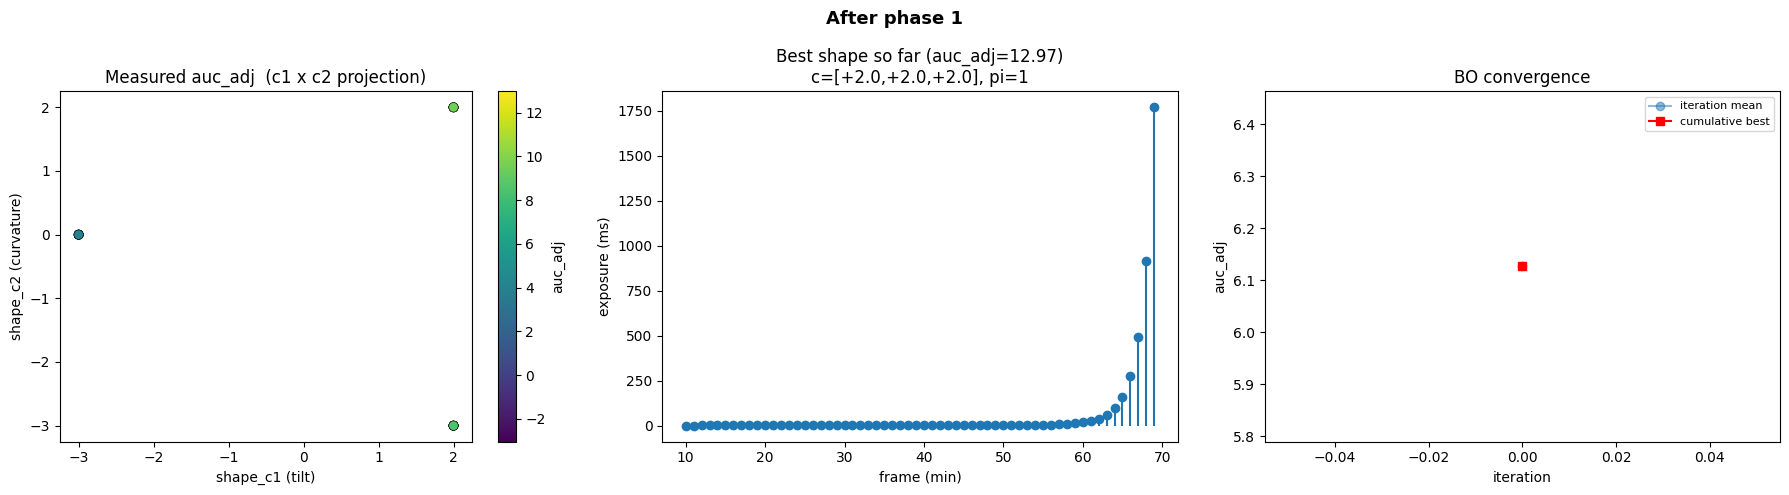


=== ComposedAgent: phase 2/13 ===


C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(


[FOVFinderAgent] Phase 1 — selected FOVs:
    A8_0000: 8 cells (rejected: below_min_cells)
    A8_0001: 8 cells (rejected: below_min_cells)
    A8_0002: 8 cells (rejected: below_min_cells)
    A9_0000: 11 cells (rejected: below_min_cells)
    A9_0001: 8 cells (rejected: below_min_cells)
    A9_0002: 5 cells (rejected: below_min_cells)
    A10_0000: 12 cells (rejected: below_min_cells)
    A10_0001: 5 cells (rejected: below_min_cells)
    A10_0002: 3 cells (rejected: below_min_cells)
    A11_0000: 3 cells (rejected: below_min_cells)
    A11_0001: 3 cells (rejected: below_min_cells)
    A11_0002: 3 cells (rejected: below_min_cells)
    A12_0000: 2 cells (rejected: below_min_cells)
    A12_0001: 1 cells (rejected: below_min_cells)
    A12_0002: 1 cells (rejected: below_min_cells)
    B12_0000: 6 cells (rejected: below_min_cells)
    B12_0001: 4 cells (rejected: below_min_cells)
    B12_0002: 2 cells (rejected: below_min_cells)
=== Phase 1: initial batch 2/2 ===
  Condition 0: {'shape_c1':

C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(
C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(
C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(
C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a bo

  [Level-3] nuisance fit on 104 cells: slope_baseline=-18.548, slope_logexpr=+1.779, R2=0.171
  Phase 1: 15 FOVs, mean auc_adj=8.937, max=24.146, mean frac_responders=0.53
  [save_model] no model to save (BO has not fit yet)


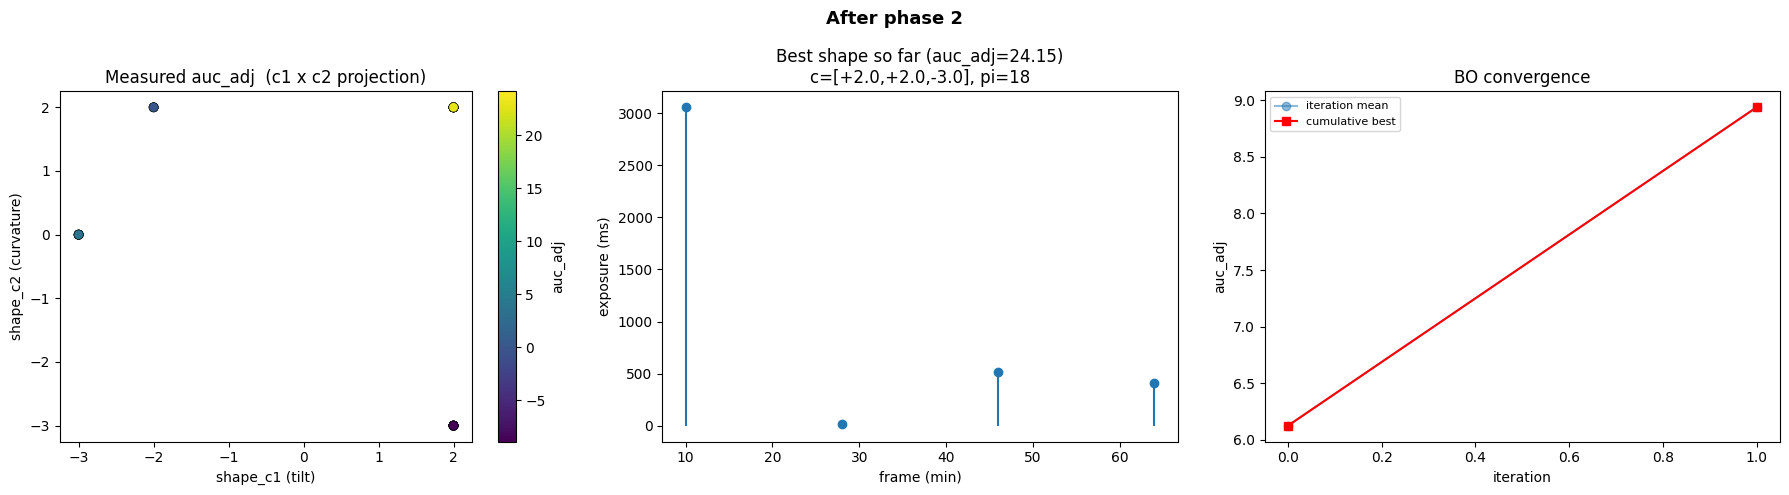


=== ComposedAgent: phase 3/13 ===


C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(


[FOVFinderAgent] Phase 2 — selected FOVs:
    B11_0000: 5 cells (rejected: below_min_cells)
    B11_0001: 3 cells (rejected: below_min_cells)
    B11_0002: 2 cells (rejected: below_min_cells)
    B10_0000: 18 cells (rejected: below_min_cells)
    B10_0001: 9 cells (rejected: below_min_cells)
    B10_0002: 6 cells (rejected: below_min_cells)
    B9_0000: 8 cells (rejected: below_min_cells)
    B9_0001: 8 cells (rejected: below_min_cells)
    B9_0002: 7 cells (rejected: below_min_cells)
    B8_0000: 26 cells (rejected: below_min_cells)
    B8_0001: 16 cells (rejected: below_min_cells)
    B8_0002: 14 cells (rejected: below_min_cells)
    B7_0000: 47 cells  cnr(mean=1.008, 53% below 1) (rejected: condition_failed:cnr_below_1.0@0.70)
    B7_0001: 31 cells (rejected: below_min_cells)
    B7_0002: 19 cells (rejected: below_min_cells)
    B6_0000: 35 cells  cnr(mean=0.870, 71% below 1)
    B6_0001: 21 cells (rejected: below_min_cells)
    B6_0002: 19 cells (rejected: below_min_cells)


sample: 100%|##########| 1200/1200 [00:02<00:00, 436.57it/s, 7 steps of size 5.96e-01. acc. prob=0.90]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.75      1.99      1.12      0.03      3.90    804.10      1.00
k_length[1]      2.10      2.56      1.24      0.07      4.89    822.60      1.00
k_length[2]      1.97      2.31      1.21      0.08      4.54    712.97      1.00
k_length[3]      1.97      2.44      1.15      0.06      4.38    849.39      1.00
k_length[4]      1.01      1.31      0.67      0.04      1.98    867.55      1.00
    k_scale      0.52      0.36      0.42      0.05      1.04    797.83      1.00
      noise      0.80      0.27      0.75      0.42      1.19    869.49      1.00

Computing robust acquisition over 109664 scenarios (6854 grid points x 16 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.415442
  Robust acq stats: min=0.037744, max=0.214814
  [reusing cached GP fit from earlier in this batch]
  [cached predict] reusing predictions for 6853 grid points x 16 covariate samples
 

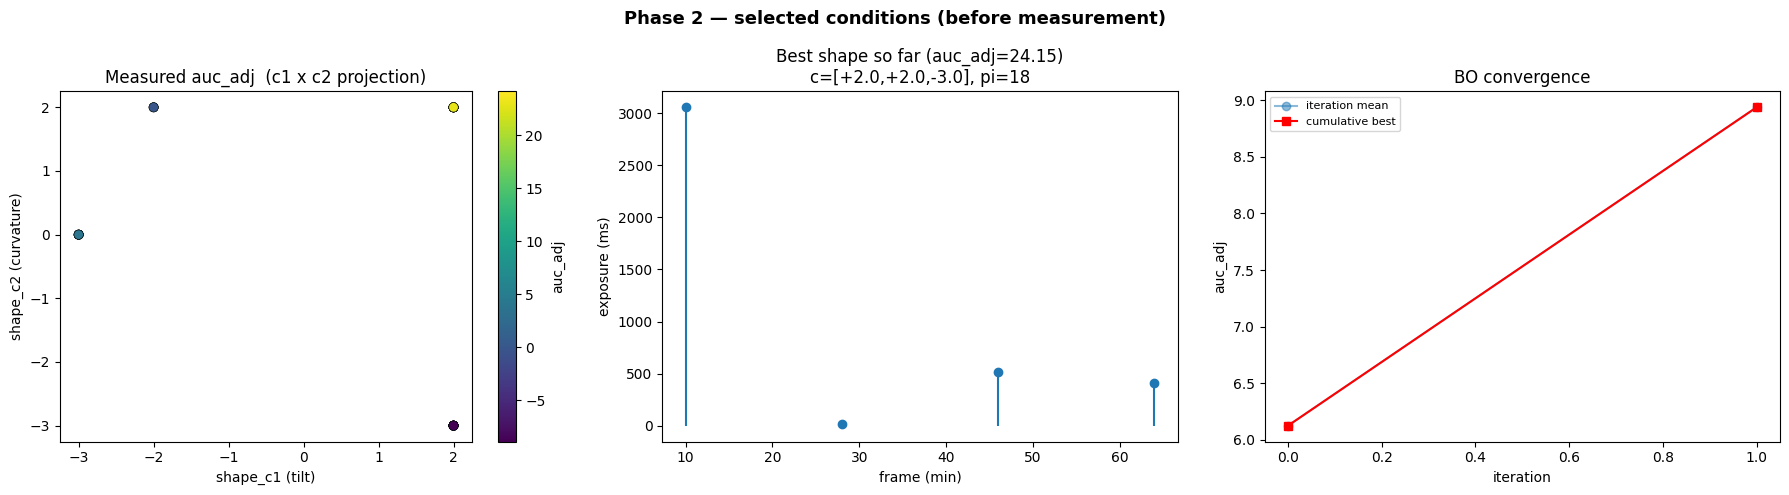

  Cond 0: dropped 1/4 sub-25ms pulses, renormalised to budget
  Cond 1: dropped 2/4 sub-25ms pulses, renormalised to budget
  Cond 2: dropped 15/30 sub-25ms pulses, renormalised to budget
  Created 1620 events for phase 2
    Cond 0 (FOVs 36-41): c=[+2.0,+2.0,-3.0], pulse_interval=19min, n_pulses=4, peak=3058ms
    Cond 1 (FOVs 42-47): c=[+3.0,-3.0,-3.0], pulse_interval=18min, n_pulses=4, peak=3938ms
    Cond 2 (FOVs 48-53): c=[+3.0,+2.0,-3.0], pulse_interval=2min, n_pulses=30, peak=537ms


C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(


  [Level-3] nuisance fit on 265 cells: slope_baseline=-34.818, slope_logexpr=+0.780, R2=0.296
  Phase 2: 17 FOVs, mean auc_adj=11.693, max=23.601, mean frac_responders=0.65


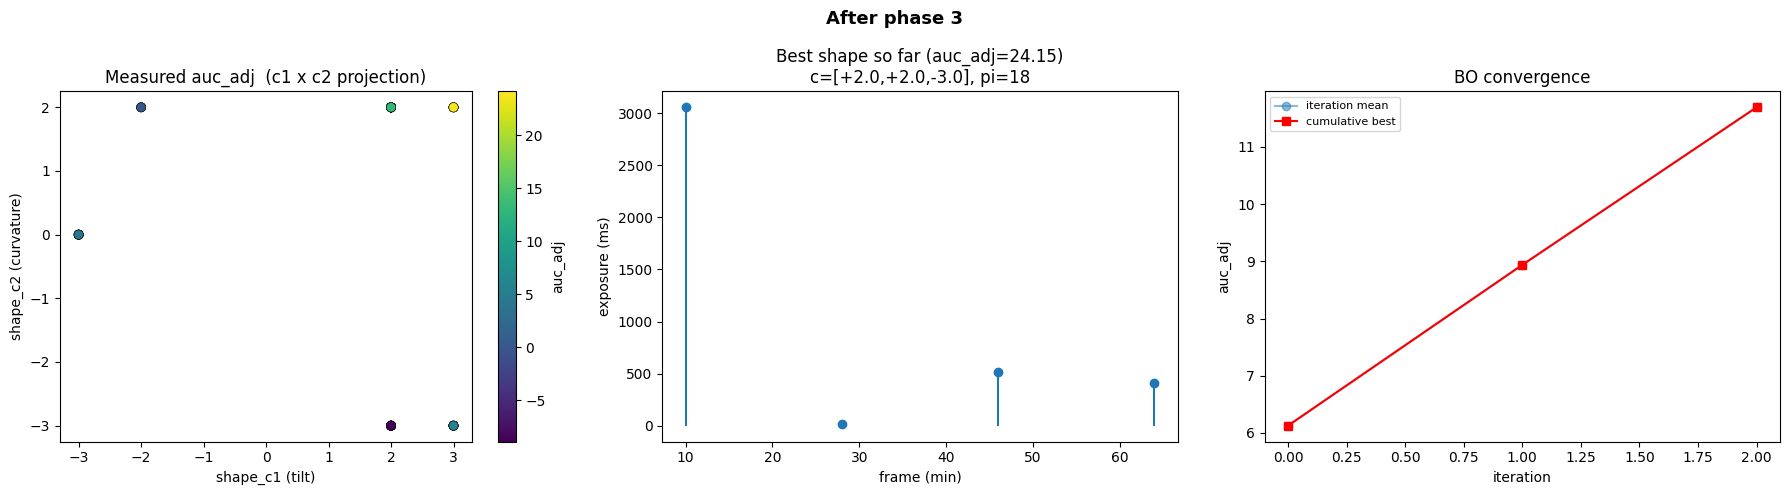


=== ComposedAgent: phase 4/13 ===


C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(


[FOVFinderAgent] Phase 3 — selected FOVs:
    B5_0000: 47 cells  cnr(mean=1.057, 43% below 1) (rejected: condition_failed:cnr_below_1.0@0.70)
    B5_0001: 11 cells (rejected: below_min_cells)
    B5_0002: 10 cells (rejected: below_min_cells)
    B4_0000: 8 cells (rejected: below_min_cells)
    B4_0001: 7 cells (rejected: below_min_cells)
    B4_0002: 6 cells (rejected: below_min_cells)
    B3_0000: 13 cells (rejected: below_min_cells)
    B3_0001: 12 cells (rejected: below_min_cells)
    B3_0002: 9 cells (rejected: below_min_cells)
    B2_0000: 17 cells (rejected: below_min_cells)
    B2_0001: 13 cells (rejected: below_min_cells)
    B2_0002: 5 cells (rejected: below_min_cells)
    C2_0000: 23 cells (rejected: below_min_cells)
    C2_0001: 6 cells (rejected: below_min_cells)
    C2_0002: 2 cells (rejected: below_min_cells)
    C3_0000: 10 cells (rejected: below_min_cells)
    C3_0001: 7 cells (rejected: below_min_cells)
    C3_0002: 6 cells (rejected: below_min_cells)


sample: 100%|##########| 1200/1200 [00:02<00:00, 413.58it/s, 7 steps of size 6.14e-01. acc. prob=0.87]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      2.26      2.66      1.43      0.09      4.64    900.68      1.00
k_length[1]      1.81      1.87      1.23      0.07      3.89    740.01      1.00
k_length[2]      2.30      2.32      1.56      0.07      5.14    910.83      1.00
k_length[3]      2.61      3.09      1.79      0.13      5.48    829.40      1.00
k_length[4]      1.42      1.20      1.14      0.09      2.61    708.61      1.00
    k_scale      0.70      0.46      0.58      0.15      1.24    785.95      1.00
      noise      0.64      0.17      0.62      0.35      0.89    864.54      1.00

Computing robust acquisition over 109616 scenarios (6851 grid points x 16 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.325522
  Robust acq stats: min=0.029209, max=0.235424
  [reusing cached GP fit from earlier in this batch]
  [cached predict] reusing predictions for 6850 grid points x 16 covariate samples
 

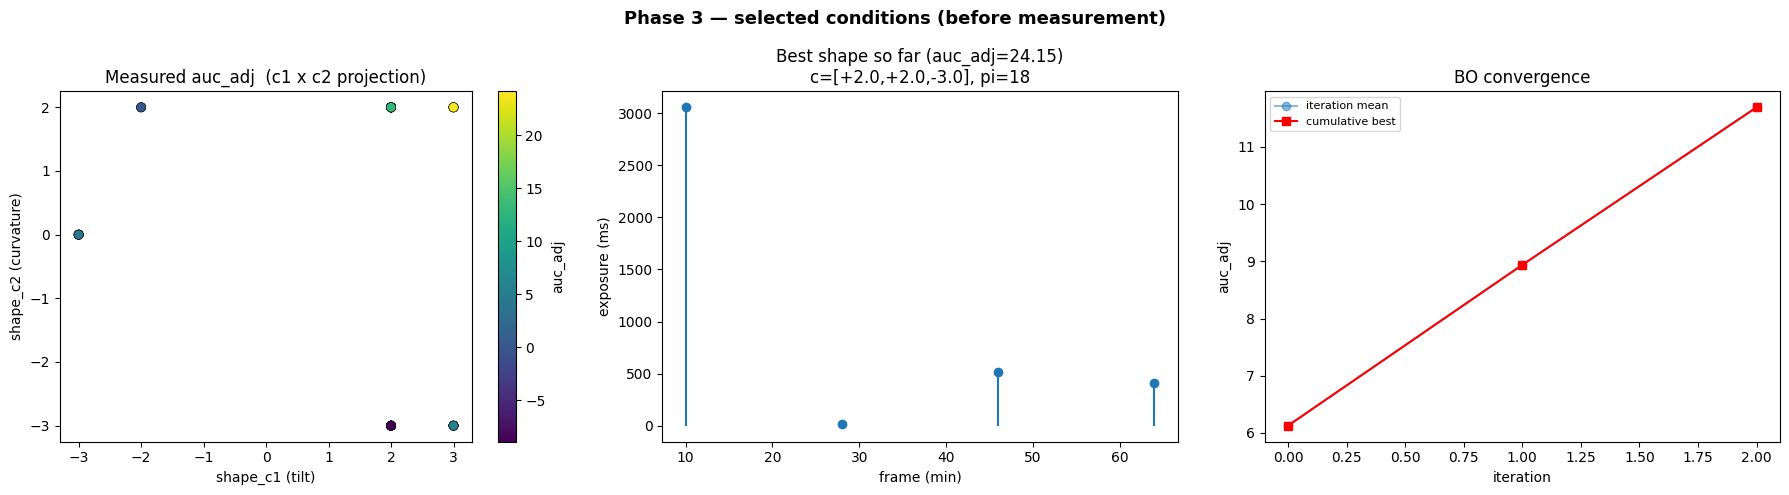

  Cond 0: dropped 9/20 sub-25ms pulses, renormalised to budget
  Cond 1: dropped 54/60 sub-25ms pulses, renormalised to budget
  Cond 2: dropped 2/6 sub-25ms pulses, renormalised to budget
  Created 1620 events for phase 3
    Cond 0 (FOVs 54-59): c=[+3.0,+2.0,-3.0], pulse_interval=3min, n_pulses=20, peak=782ms
    Cond 1 (FOVs 60-65): c=[-1.0,+3.0,-3.0], pulse_interval=1min, n_pulses=60, peak=2281ms
    Cond 2 (FOVs 66-71): c=[+3.0,+3.0,-3.0], pulse_interval=11min, n_pulses=6, peak=1306ms
  [Level-3] nuisance fit on 350 cells: slope_baseline=-36.797, slope_logexpr=+1.151, R2=0.306
  Phase 3: 17 FOVs, mean auc_adj=10.601, max=24.147, mean frac_responders=0.45


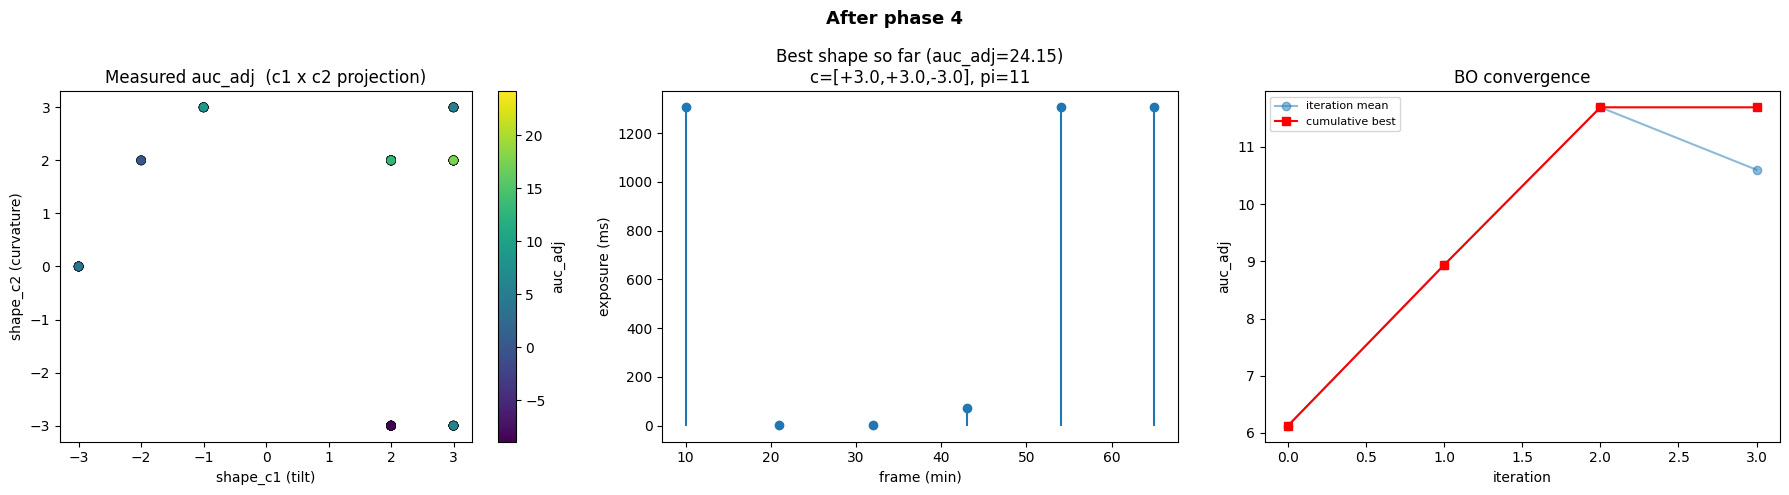


=== ComposedAgent: phase 5/13 ===


C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(


[FOVFinderAgent] Phase 4 — selected FOVs:
    C4_0000: 12 cells (rejected: below_min_cells)
    C4_0001: 7 cells (rejected: below_min_cells)
    C4_0002: 6 cells (rejected: below_min_cells)
    C5_0000: 18 cells (rejected: below_min_cells)
    C5_0001: 16 cells (rejected: below_min_cells)
    C5_0002: 10 cells (rejected: below_min_cells)
    C6_0000: 11 cells (rejected: below_min_cells)
    C6_0001: 10 cells (rejected: below_min_cells)
    C6_0002: 10 cells (rejected: below_min_cells)
    C7_0000: 28 cells (rejected: below_min_cells)
    C7_0001: 23 cells (rejected: below_min_cells)
    C7_0002: 22 cells (rejected: below_min_cells)
    C8_0000: 18 cells (rejected: below_min_cells)
    C8_0001: 5 cells (rejected: below_min_cells)
    C8_0002: 5 cells (rejected: below_min_cells)
    C9_0000: 9 cells (rejected: below_min_cells)
    C9_0001: 7 cells (rejected: below_min_cells)
    C9_0002: 6 cells (rejected: below_min_cells)


sample: 100%|##########| 1200/1200 [00:04<00:00, 295.90it/s, 7 steps of size 5.91e-01. acc. prob=0.90]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.86      1.74      1.39      0.14      3.78    670.68      1.00
k_length[1]      1.89      1.78      1.39      0.08      3.99    951.91      1.00
k_length[2]      2.40      2.18      1.73      0.15      5.07    771.25      1.00
k_length[3]      3.41      3.70      2.48      0.14      6.98    716.06      1.00
k_length[4]      1.54      1.19      1.25      0.18      3.04   1057.32      1.01
    k_scale      0.63      0.40      0.55      0.18      1.06    871.75      1.00
      noise      0.66      0.14      0.65      0.45      0.88   1197.45      1.00

Computing robust acquisition over 109568 scenarios (6848 grid points x 16 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.515849
  Robust acq stats: min=0.018271, max=0.180907
  [reusing cached GP fit from earlier in this batch]
  [cached predict] reusing predictions for 6847 grid points x 16 covariate samples
 

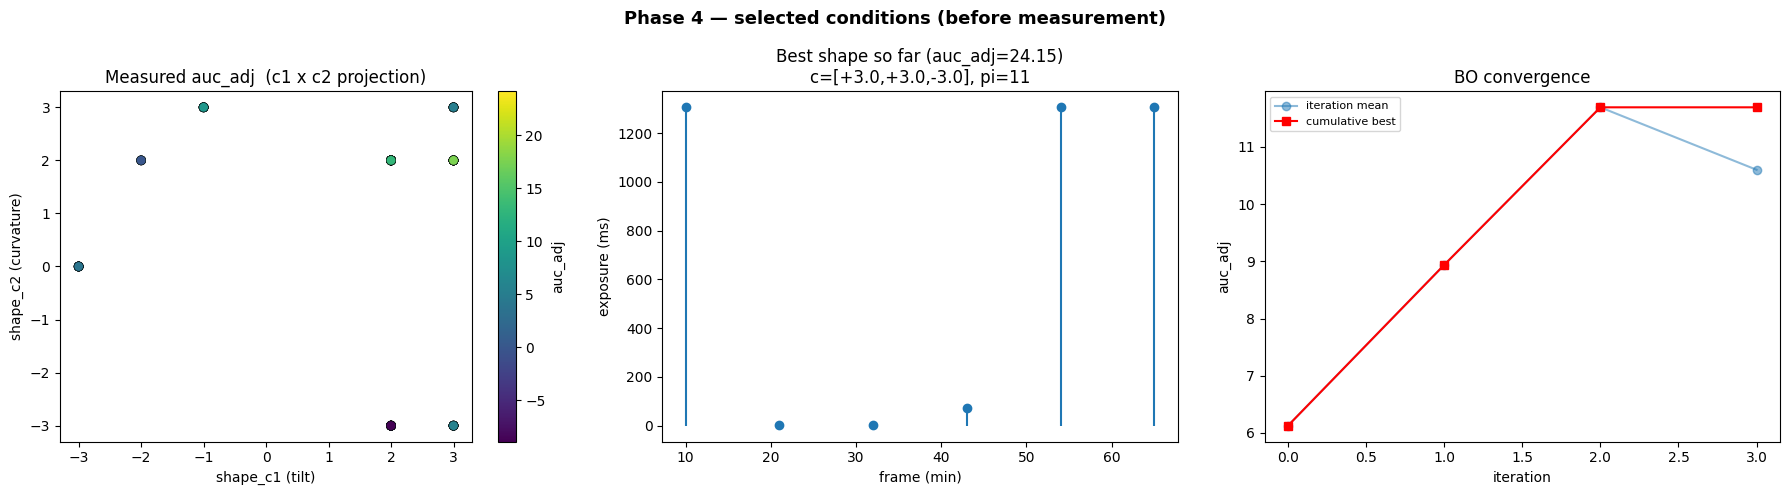

  Cond 0: dropped 35/60 sub-25ms pulses, renormalised to budget
  Cond 1: dropped 4/7 sub-25ms pulses, renormalised to budget
  Cond 2: dropped 2/7 sub-25ms pulses, renormalised to budget
  Created 1620 events for phase 4
    Cond 0 (FOVs 72-77): c=[+3.0,+2.0,-3.0], pulse_interval=1min, n_pulses=60, peak=270ms
    Cond 1 (FOVs 78-83): c=[+3.0,+2.0,+0.0], pulse_interval=9min, n_pulses=7, peak=3682ms
    Cond 2 (FOVs 84-89): c=[+3.0,+1.0,-3.0], pulse_interval=9min, n_pulses=7, peak=2389ms
  [Level-3] nuisance fit on 465 cells: slope_baseline=-32.883, slope_logexpr=+0.584, R2=0.245
  Phase 4: 17 FOVs, mean auc_adj=10.804, max=22.289, mean frac_responders=0.60


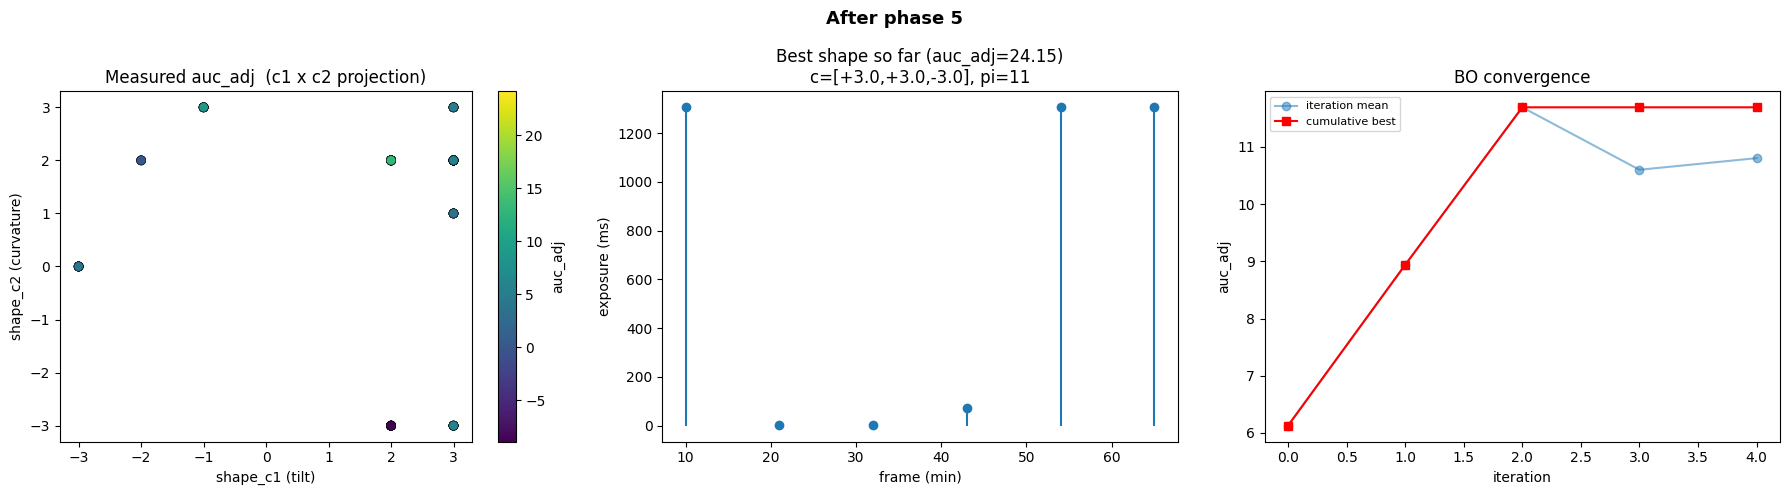


=== ComposedAgent: phase 6/13 ===


C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(
no seeds found in get_masks_torch - no masks found.


[FOVFinderAgent] Phase 5 — selected FOVs:
    C10_0000: 11 cells (rejected: below_min_cells)
    C10_0001: 5 cells (rejected: below_min_cells)
    C10_0002: 4 cells (rejected: below_min_cells)
    C11_0000: 6 cells (rejected: below_min_cells)
    C11_0001: 5 cells (rejected: below_min_cells)
    C11_0002: 3 cells (rejected: below_min_cells)
    C12_0000: 8 cells (rejected: below_min_cells)
    C12_0001: 6 cells (rejected: below_min_cells)
    C12_0002: 6 cells (rejected: below_min_cells)
    D12_0000: 3 cells (rejected: below_min_cells)
    D12_0001: 2 cells (rejected: below_min_cells)
    D12_0002: 1 cells (rejected: below_min_cells)
    D11_0000: 7 cells (rejected: below_min_cells)
    D11_0001: 5 cells (rejected: below_min_cells)
    D11_0002: 3 cells (rejected: below_min_cells)
    D10_0000: 23 cells (rejected: below_min_cells)
    D10_0001: 10 cells (rejected: below_min_cells)
    D10_0002: 9 cells (rejected: below_min_cells)


sample: 100%|##########| 1200/1200 [00:04<00:00, 245.80it/s, 3 steps of size 5.79e-01. acc. prob=0.90]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      2.12      2.15      1.47      0.12      4.40    684.58      1.00
k_length[1]      2.18      2.30      1.53      0.11      4.57    839.88      1.00
k_length[2]      1.80      2.08      1.18      0.04      3.82    465.43      1.00
k_length[3]      3.27      3.45      2.32      0.13      6.78    761.46      1.00
k_length[4]      1.44      1.23      1.05      0.13      2.98    882.77      1.00
    k_scale      0.53      0.35      0.45      0.15      0.90    587.91      1.00
      noise      0.72      0.14      0.71      0.50      0.94    740.70      1.00

Computing robust acquisition over 109520 scenarios (6845 grid points x 16 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.374744
  Robust acq stats: min=0.024787, max=0.158424
  [reusing cached GP fit from earlier in this batch]
  [cached predict] reusing predictions for 6844 grid points x 16 covariate samples
 

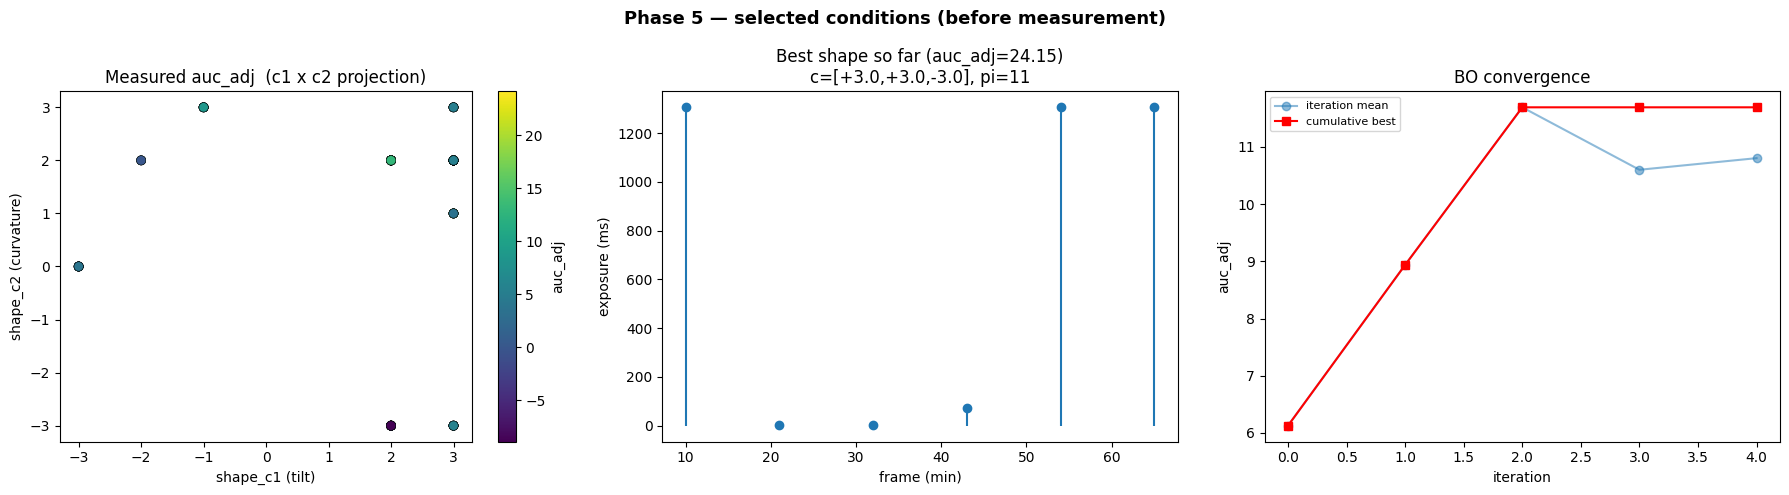

  Cond 0: dropped 4/10 sub-25ms pulses, renormalised to budget
  Cond 1: dropped 35/60 sub-25ms pulses, renormalised to budget
  Cond 2: dropped 2/3 sub-25ms pulses, renormalised to budget
  Created 1620 events for phase 5
    Cond 0 (FOVs 90-95): c=[+3.0,+1.0,-3.0], pulse_interval=6min, n_pulses=10, peak=1486ms
    Cond 1 (FOVs 96-101): c=[-3.0,-3.0,+3.0], pulse_interval=1min, n_pulses=60, peak=276ms
    Cond 2 (FOVs 102-107): c=[-3.0,+3.0,-3.0], pulse_interval=20min, n_pulses=3, peak=4000ms


C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(
C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(
C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(
C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a bo

  [Level-3] nuisance fit on 510 cells: slope_baseline=-29.491, slope_logexpr=+0.179, R2=0.207
  Phase 5: 16 FOVs, mean auc_adj=5.758, max=15.849, mean frac_responders=0.21


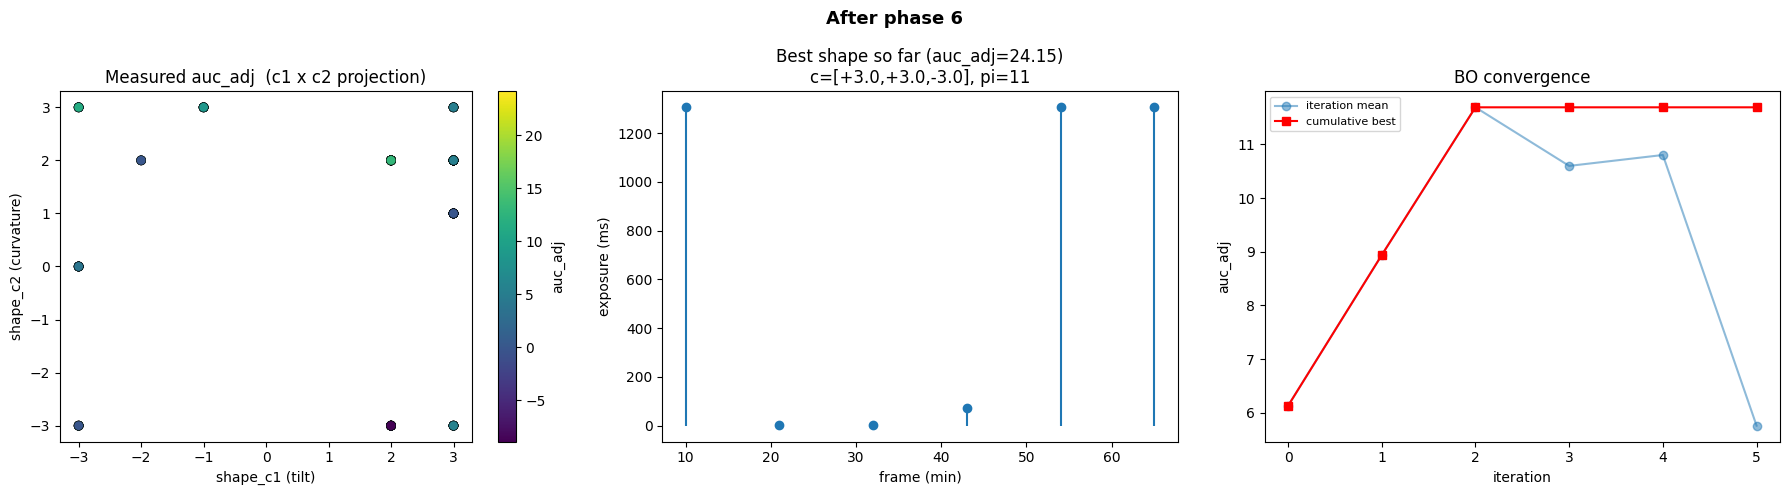


=== ComposedAgent: phase 7/13 ===


C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(
no seeds found in get_masks_torch - no masks found.
C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(
C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(


[FOVFinderAgent] Phase 6 — selected FOVs:
    D9_0000: 37 cells  cnr(mean=0.959, 56% below 1) (rejected: condition_failed:cnr_below_1.0@0.70)
    D9_0001: 15 cells (rejected: below_min_cells)
    D9_0002: 8 cells (rejected: below_min_cells)
    D8_0000: 7 cells (rejected: below_min_cells)
    D8_0001: 6 cells (rejected: below_min_cells)
    D8_0002: 5 cells (rejected: below_min_cells)
    D7_0000: 40 cells  cnr(mean=0.881, 61% below 1) (rejected: condition_failed:cnr_below_1.0@0.70)
    D7_0001: 23 cells (rejected: below_min_cells)
    D7_0002: 18 cells (rejected: below_min_cells)
    D6_0000: 19 cells (rejected: below_min_cells)
    D6_0001: 8 cells (rejected: below_min_cells)
    D6_0002: 7 cells (rejected: below_min_cells)
    D5_0000: 21 cells (rejected: below_min_cells)
    D5_0001: 20 cells (rejected: below_min_cells)
    D5_0002: 10 cells (rejected: below_min_cells)
    D4_0000: 44 cells  cnr(mean=0.957, 45% below 1) (rejected: condition_failed:cnr_below_1.0@0.70)
    D4_0001: 2

sample: 100%|##########| 1200/1200 [00:06<00:00, 199.88it/s, 7 steps of size 5.02e-01. acc. prob=0.92]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      2.07      1.98      1.47      0.14      4.02    655.89      1.00
k_length[1]      3.45      3.13      2.51      0.34      7.09    756.46      1.00
k_length[2]      2.62      2.75      1.80      0.06      5.87    857.26      1.00
k_length[3]      3.71      3.48      2.84      0.33      6.94    758.46      1.00
k_length[4]      0.66      0.60      0.49      0.09      1.21    644.92      1.00
    k_scale      0.50      0.25      0.46      0.17      0.84    956.59      1.00
      noise      0.66      0.12      0.65      0.45      0.82   1033.70      1.00

Computing robust acquisition over 109472 scenarios (6842 grid points x 16 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): -0.073569
  Robust acq stats: min=0.107655, max=0.264637
  [reusing cached GP fit from earlier in this batch]
  [cached predict] reusing predictions for 6841 grid points x 16 covariate samples


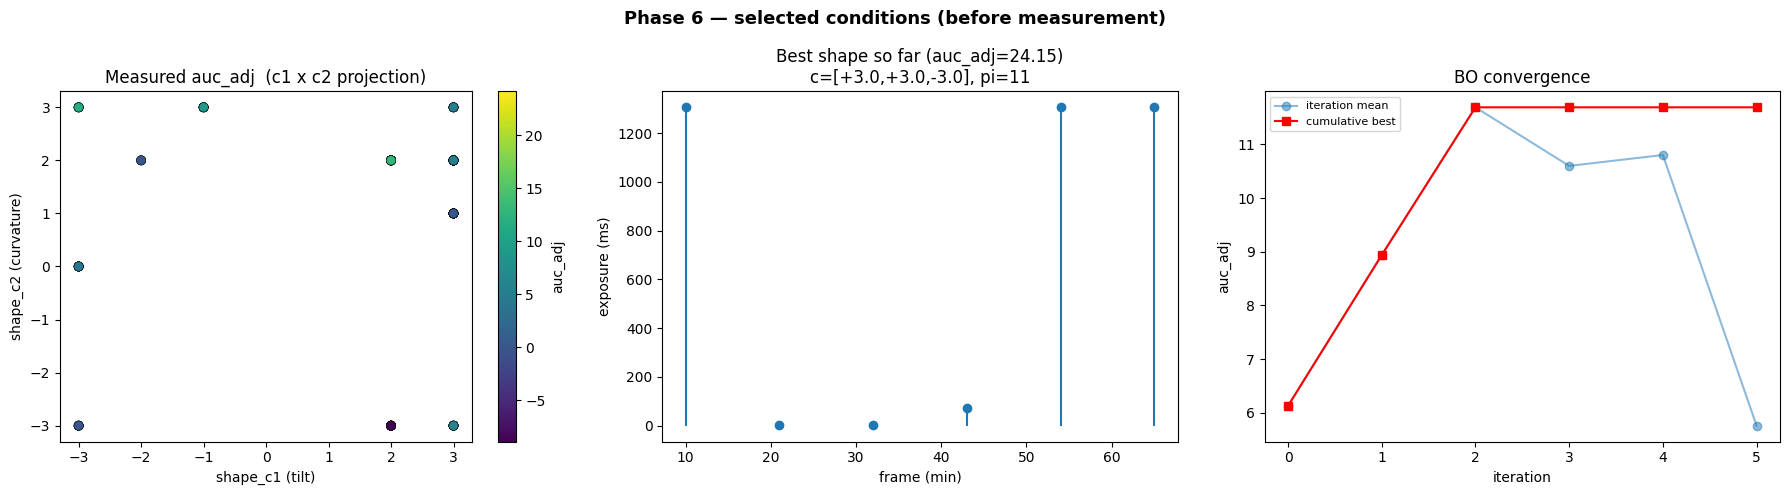

  Cond 0: dropped 10/20 sub-25ms pulses, renormalised to budget
  Cond 1: dropped 2/3 sub-25ms pulses, renormalised to budget
  Cond 2: dropped 15/60 sub-25ms pulses, renormalised to budget
  Created 1620 events for phase 6
    Cond 0 (FOVs 108-113): c=[+3.0,+3.0,-3.0], pulse_interval=3min, n_pulses=20, peak=797ms
    Cond 1 (FOVs 114-119): c=[+3.0,+3.0,+3.0], pulse_interval=20min, n_pulses=3, peak=4000ms
    Cond 2 (FOVs 120-125): c=[+3.0,-3.0,+3.0], pulse_interval=1min, n_pulses=60, peak=443ms
  [Level-3] nuisance fit on 678 cells: slope_baseline=-29.699, slope_logexpr=+0.216, R2=0.204
  Phase 6: 17 FOVs, mean auc_adj=10.933, max=19.349, mean frac_responders=0.62


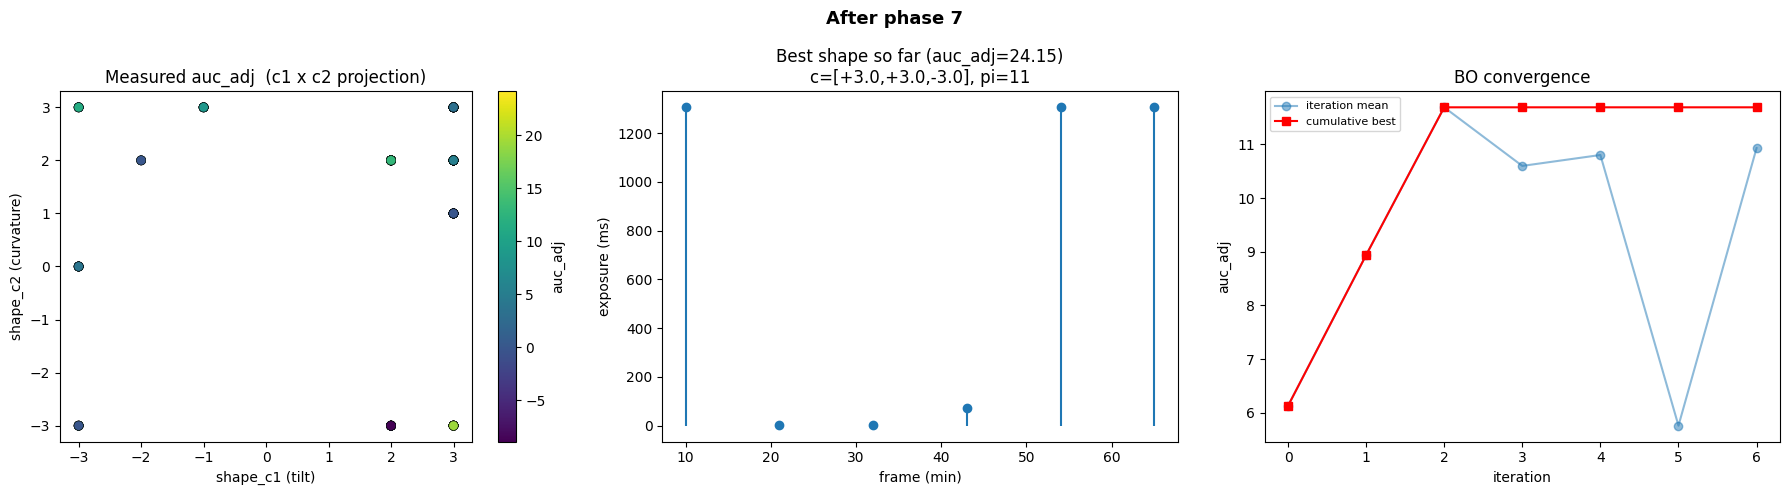


=== ComposedAgent: phase 8/13 ===


C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(


[FOVFinderAgent] Phase 7 — selected FOVs:
    D3_0000: 11 cells (rejected: below_min_cells)
    D3_0001: 9 cells (rejected: below_min_cells)
    D3_0002: 8 cells (rejected: below_min_cells)
    D2_0000: 11 cells (rejected: below_min_cells)
    D2_0001: 5 cells (rejected: below_min_cells)
    D2_0002: 4 cells (rejected: below_min_cells)
    E2_0000: 21 cells (rejected: below_min_cells)
    E2_0001: 12 cells (rejected: below_min_cells)
    E2_0002: 9 cells (rejected: below_min_cells)
    E3_0000: 24 cells (rejected: below_min_cells)
    E3_0001: 7 cells (rejected: below_min_cells)
    E3_0002: 6 cells (rejected: below_min_cells)
    E4_0000: 19 cells (rejected: below_min_cells)
    E4_0001: 9 cells (rejected: below_min_cells)
    E4_0002: 6 cells (rejected: below_min_cells)
    E5_0000: 22 cells (rejected: below_min_cells)
    E5_0001: 22 cells (rejected: below_min_cells)
    E5_0002: 6 cells (rejected: below_min_cells)


sample: 100%|##########| 1200/1200 [00:06<00:00, 172.45it/s, 7 steps of size 5.03e-01. acc. prob=0.90]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      2.47      3.62      1.77      0.24      4.66    817.52      1.00
k_length[1]      3.17      3.04      2.30      0.28      6.34    704.96      1.00
k_length[2]      2.62      2.81      1.98      0.13      4.84    498.80      1.00
k_length[3]      3.33      3.01      2.50      0.47      6.15    730.11      1.00
k_length[4]      0.86      0.65      0.65      0.19      1.72    684.91      1.00
    k_scale      0.55      0.26      0.50      0.22      0.95    802.54      1.00
      noise      0.66      0.11      0.65      0.47      0.80    974.44      1.00

Computing robust acquisition over 109424 scenarios (6839 grid points x 16 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.231916
  Robust acq stats: min=0.031201, max=0.201604
  [reusing cached GP fit from earlier in this batch]
  [cached predict] reusing predictions for 6838 grid points x 16 covariate samples
 

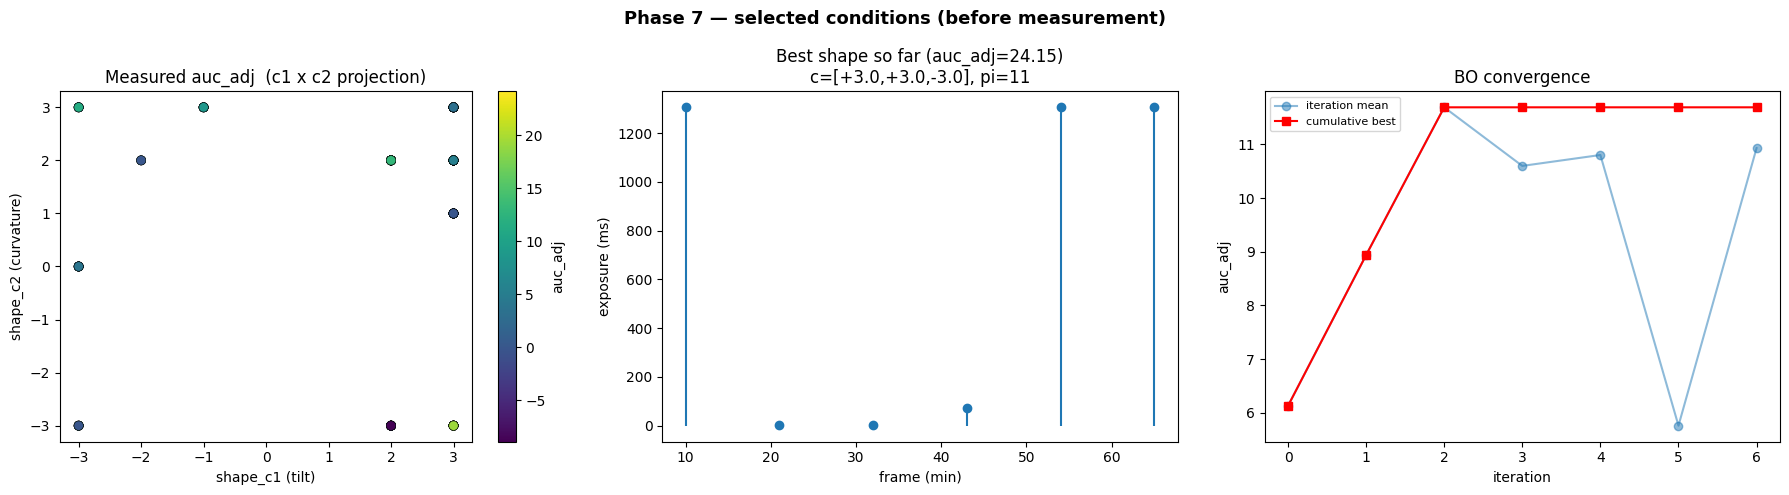

  Cond 0: dropped 2/7 sub-25ms pulses, renormalised to budget
  Cond 1: dropped 27/60 sub-25ms pulses, renormalised to budget
  Cond 2: dropped 26/60 sub-25ms pulses, renormalised to budget
  Created 1620 events for phase 7
    Cond 0 (FOVs 126-131): c=[+2.0,+1.0,-3.0], pulse_interval=9min, n_pulses=7, peak=1644ms
    Cond 1 (FOVs 132-137): c=[+1.0,+0.0,-3.0], pulse_interval=1min, n_pulses=60, peak=243ms
    Cond 2 (FOVs 138-143): c=[+3.0,-1.0,+0.0], pulse_interval=1min, n_pulses=60, peak=183ms
  [Level-3] nuisance fit on 775 cells: slope_baseline=-25.755, slope_logexpr=+1.447, R2=0.179
  Phase 7: 17 FOVs, mean auc_adj=9.681, max=20.508, mean frac_responders=0.46


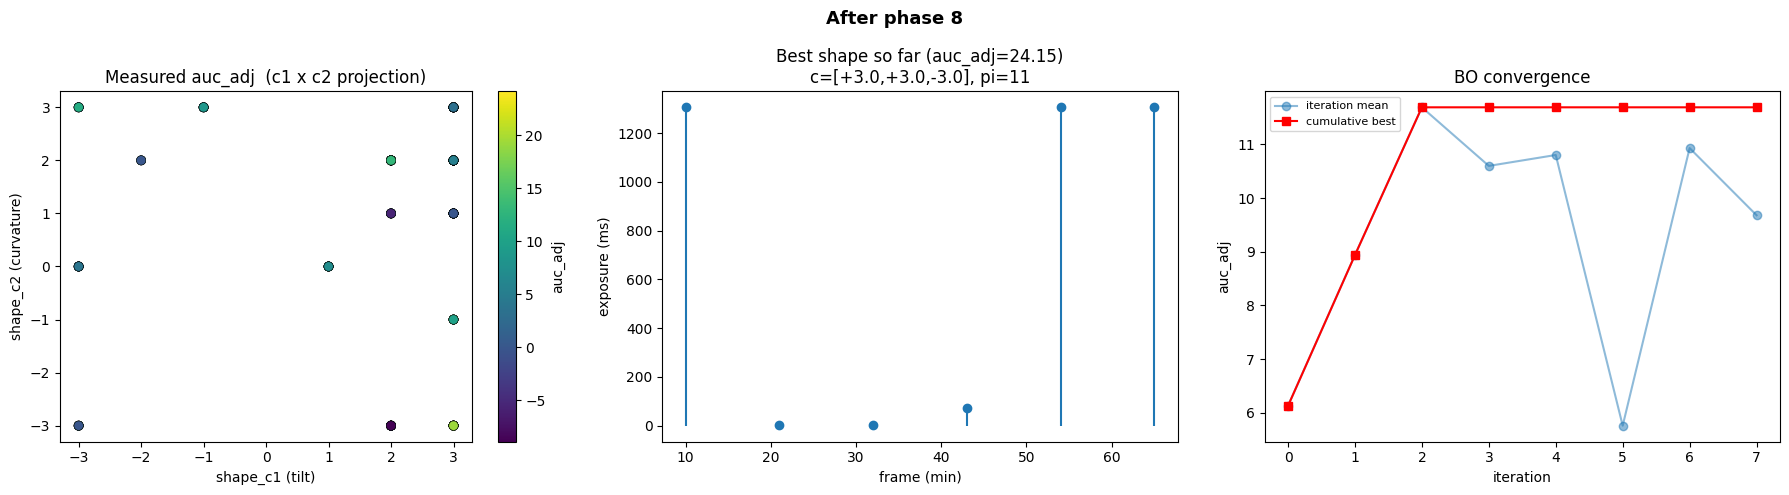


=== ComposedAgent: phase 9/13 ===


C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(


[FOVFinderAgent] Phase 8 — selected FOVs:
    E6_0000: 13 cells (rejected: below_min_cells)
    E6_0001: 9 cells (rejected: below_min_cells)
    E6_0002: 4 cells (rejected: below_min_cells)
    E7_0000: 25 cells (rejected: below_min_cells)
    E7_0001: 14 cells (rejected: below_min_cells)
    E7_0002: 14 cells (rejected: below_min_cells)
    E8_0000: 18 cells (rejected: below_min_cells)
    E8_0001: 12 cells (rejected: below_min_cells)
    E8_0002: 6 cells (rejected: below_min_cells)
    E9_0000: 9 cells (rejected: below_min_cells)
    E9_0001: 8 cells (rejected: below_min_cells)
    E9_0002: 8 cells (rejected: below_min_cells)
    E10_0000: 14 cells (rejected: below_min_cells)
    E10_0001: 12 cells (rejected: below_min_cells)
    E10_0002: 11 cells (rejected: below_min_cells)
    E11_0000: 15 cells (rejected: below_min_cells)
    E11_0001: 11 cells (rejected: below_min_cells)
    E11_0002: 5 cells (rejected: below_min_cells)


sample: 100%|##########| 1200/1200 [00:11<00:00, 103.87it/s, 7 steps of size 5.49e-01. acc. prob=0.91]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      3.02      3.04      2.32      0.29      5.65    704.13      1.00
k_length[1]      2.77      2.53      2.07      0.35      5.38    590.07      1.00
k_length[2]      3.01      2.57      2.29      0.18      5.89    716.80      1.00
k_length[3]      3.30      3.40      2.30      0.26      6.43    613.28      1.00
k_length[4]      1.40      0.90      1.19      0.21      2.53    815.59      1.01
    k_scale      0.53      0.31      0.45      0.17      0.93    749.62      1.00
      noise      0.73      0.10      0.72      0.56      0.87    938.07      1.00

Computing robust acquisition over 109376 scenarios (6836 grid points x 16 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.344454
  Robust acq stats: min=0.017995, max=0.159593
  [reusing cached GP fit from earlier in this batch]
  [cached predict] reusing predictions for 6835 grid points x 16 covariate samples
 

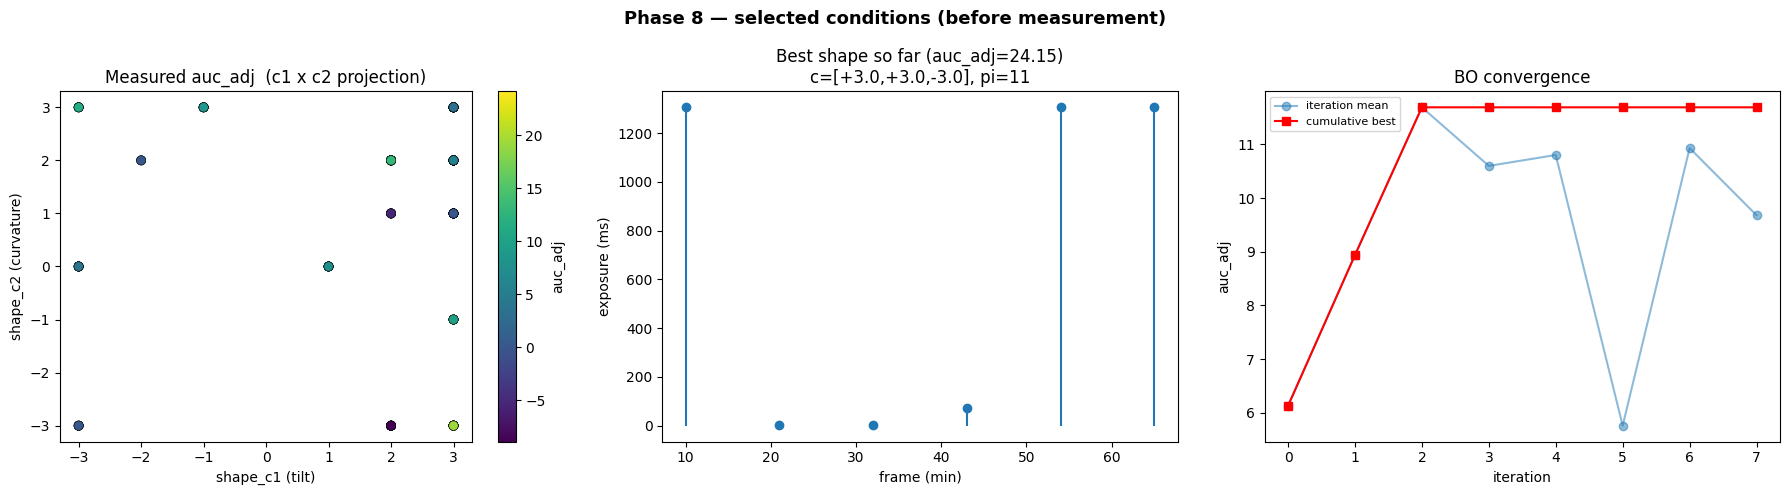

  Cond 0: dropped 33/60 sub-25ms pulses, renormalised to budget
  Cond 1: dropped 22/60 sub-25ms pulses, renormalised to budget
  Cond 2: dropped 28/60 sub-25ms pulses, renormalised to budget
  Created 1620 events for phase 8
    Cond 0 (FOVs 144-149): c=[+3.0,-1.0,-3.0], pulse_interval=1min, n_pulses=60, peak=267ms
    Cond 1 (FOVs 150-155): c=[+0.0,-3.0,+0.0], pulse_interval=1min, n_pulses=60, peak=162ms
    Cond 2 (FOVs 156-161): c=[+3.0,-3.0,-1.0], pulse_interval=1min, n_pulses=60, peak=204ms
  [Level-3] nuisance fit on 859 cells: slope_baseline=-26.043, slope_logexpr=+0.973, R2=0.178
  Phase 8: 17 FOVs, mean auc_adj=10.589, max=27.670, mean frac_responders=0.45


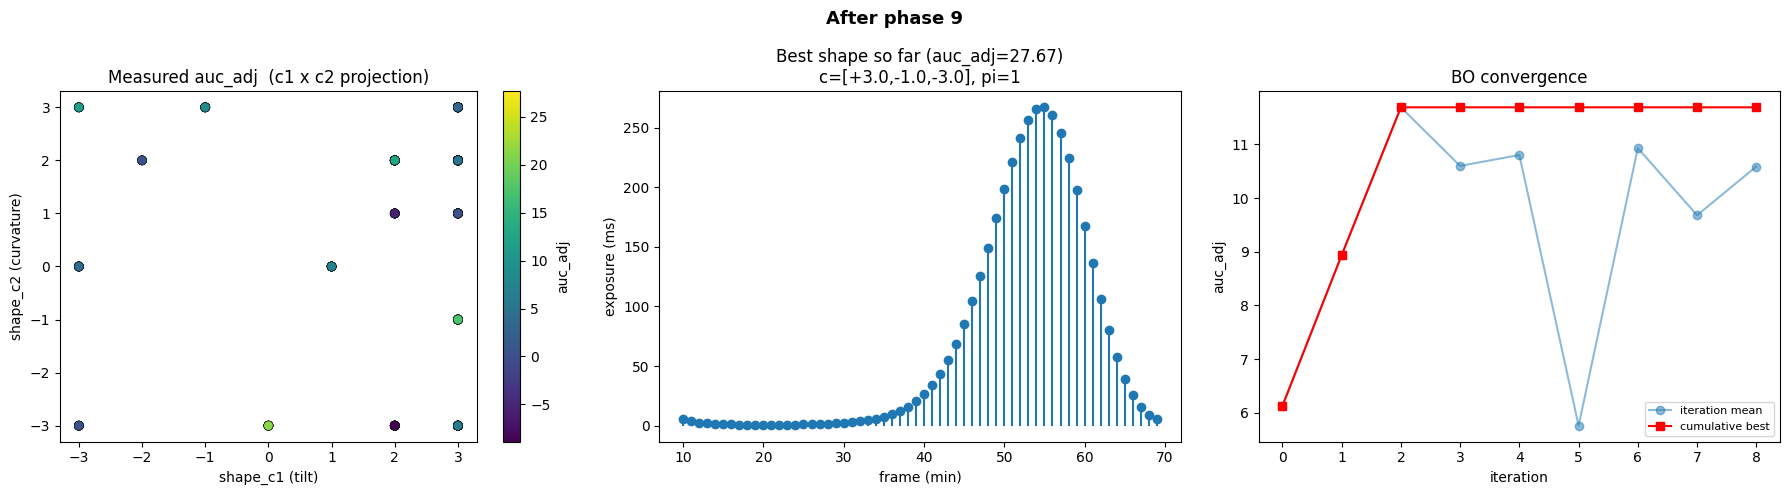


=== ComposedAgent: phase 10/13 ===


C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(
no seeds found in get_masks_torch - no masks found.


[FOVFinderAgent] Phase 9 — selected FOVs:
    E12_0000: 6 cells (rejected: below_min_cells)
    E12_0001: 5 cells (rejected: below_min_cells)
    E12_0002: 3 cells (rejected: below_min_cells)
    F12_0000: 4 cells (rejected: below_min_cells)
    F12_0001: 3 cells (rejected: below_min_cells)
    F12_0002: 3 cells (rejected: below_min_cells)
    F11_0000: 10 cells (rejected: below_min_cells)
    F11_0001: 9 cells (rejected: below_min_cells)
    F11_0002: 4 cells (rejected: below_min_cells)
    F10_0000: 8 cells (rejected: below_min_cells)
    F10_0001: 6 cells (rejected: below_min_cells)
    F10_0002: 5 cells (rejected: below_min_cells)
    F9_0000: 12 cells (rejected: below_min_cells)
    F9_0001: 10 cells (rejected: below_min_cells)
    F9_0002: 8 cells (rejected: below_min_cells)
    F8_0000: 7 cells (rejected: below_min_cells)
    F8_0001: 6 cells (rejected: below_min_cells)
    F8_0002: 6 cells (rejected: below_min_cells)


sample: 100%|##########| 1200/1200 [00:13<00:00, 90.06it/s, 7 steps of size 5.90e-01. acc. prob=0.90] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      3.04      2.83      2.34      0.23      5.73    933.67      1.01
k_length[1]      2.94      2.88      2.17      0.27      5.80    799.56      1.00
k_length[2]      2.97      2.32      2.31      0.39      6.00    900.64      1.00
k_length[3]      3.32      3.16      2.45      0.25      6.77    665.76      1.00
k_length[4]      1.69      0.99      1.46      0.24      2.99   1010.87      1.00
    k_scale      0.48      0.31      0.39      0.11      0.86    649.96      1.00
      noise      0.78      0.10      0.78      0.61      0.93    925.15      1.00

Computing robust acquisition over 109328 scenarios (6833 grid points x 16 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.110220
  Robust acq stats: min=0.025161, max=0.155066
  [reusing cached GP fit from earlier in this batch]
  [cached predict] reusing predictions for 6832 grid points x 16 covariate samples
 

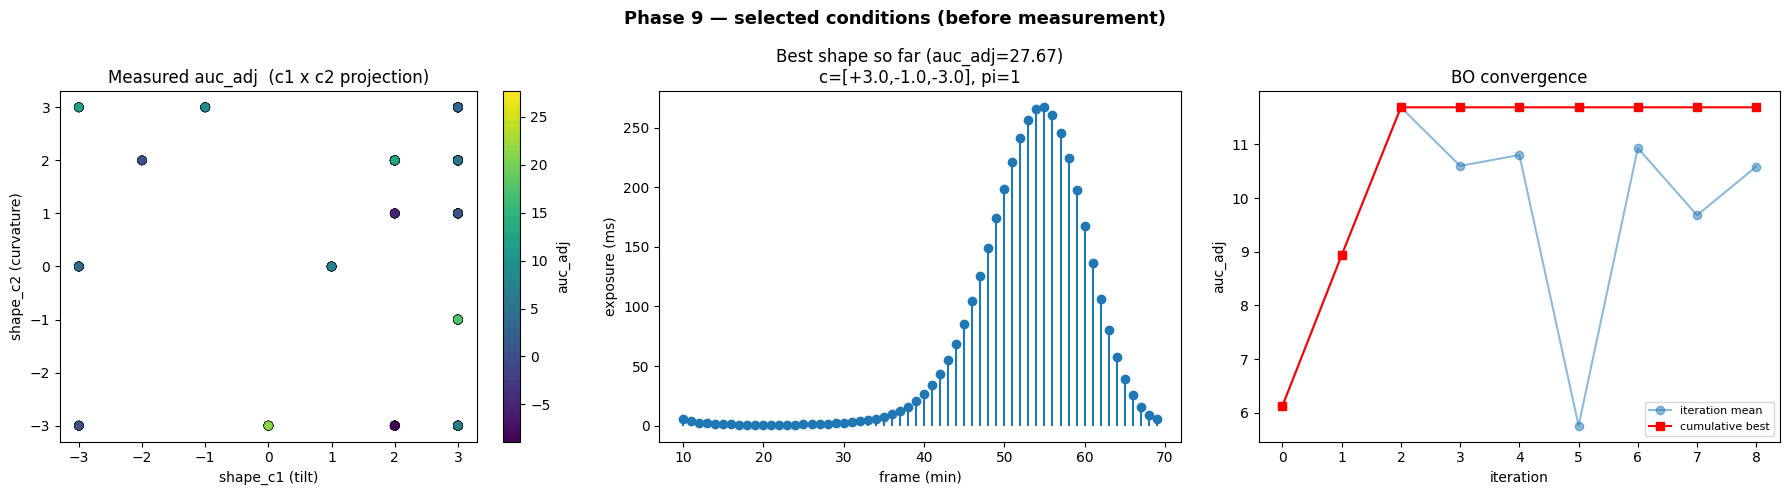

  Cond 0: dropped 34/60 sub-25ms pulses, renormalised to budget
  Cond 1: dropped 24/60 sub-25ms pulses, renormalised to budget
  Created 1620 events for phase 9
    Cond 0 (FOVs 162-167): c=[+3.0,+0.0,-3.0], pulse_interval=1min, n_pulses=60, peak=265ms
    Cond 1 (FOVs 168-173): c=[+0.0,-1.0,+3.0], pulse_interval=1min, n_pulses=60, peak=272ms
    Cond 2 (FOVs 174-179): c=[-3.0,-3.0,+3.0], pulse_interval=20min, n_pulses=3, peak=3913ms


C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(
C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(
C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(
C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a bo

  [Level-3] nuisance fit on 899 cells: slope_baseline=-24.674, slope_logexpr=+1.170, R2=0.168
  Phase 9: 16 FOVs, mean auc_adj=4.866, max=15.843, mean frac_responders=0.33


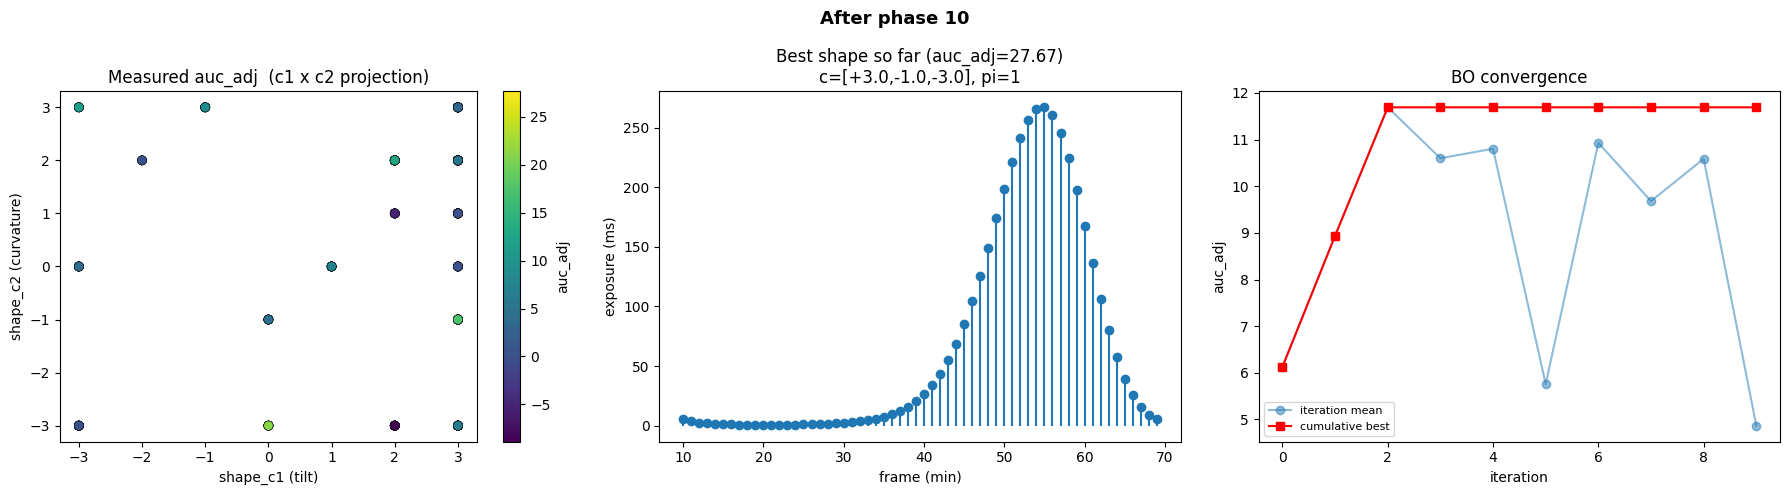


=== ComposedAgent: phase 11/13 ===


C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(
C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(


[FOVFinderAgent] Phase 10 — selected FOVs:
    F7_0000: 17 cells (rejected: below_min_cells)
    F7_0001: 17 cells (rejected: below_min_cells)
    F7_0002: 14 cells (rejected: below_min_cells)
    F6_0000: 16 cells (rejected: below_min_cells)
    F6_0001: 12 cells (rejected: below_min_cells)
    F6_0002: 12 cells (rejected: below_min_cells)
    F5_0000: 27 cells (rejected: below_min_cells)
    F5_0001: 26 cells (rejected: below_min_cells)
    F5_0002: 10 cells (rejected: below_min_cells)
    F4_0000: 29 cells (rejected: below_min_cells)
    F4_0001: 14 cells (rejected: below_min_cells)
    F4_0002: 7 cells (rejected: below_min_cells)
    F3_0000: 11 cells (rejected: below_min_cells)
    F3_0001: 9 cells (rejected: below_min_cells)
    F3_0002: 6 cells (rejected: below_min_cells)
    F2_0000: 35 cells  cnr(mean=0.983, 49% below 1) (rejected: condition_failed:cnr_below_1.0@0.70)
    F2_0001: 22 cells (rejected: below_min_cells)
    F2_0002: 10 cells (rejected: below_min_cells)


sample: 100%|##########| 1200/1200 [00:14<00:00, 82.44it/s, 7 steps of size 5.39e-01. acc. prob=0.91] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      3.50      2.74      2.79      0.51      6.68    731.75      1.00
k_length[1]      3.36      3.23      2.47      0.34      6.73    738.88      1.00
k_length[2]      3.53      3.01      2.68      0.50      6.98    732.45      1.00
k_length[3]      3.50      3.25      2.65      0.28      6.93    614.19      1.00
k_length[4]      1.76      0.98      1.55      0.42      3.15   1019.94      1.00
    k_scale      0.52      0.34      0.43      0.12      0.94    723.37      1.00
      noise      0.76      0.09      0.75      0.62      0.90   1069.21      1.00

Computing robust acquisition over 109280 scenarios (6830 grid points x 16 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.200716
  Robust acq stats: min=0.028940, max=0.184748
  [reusing cached GP fit from earlier in this batch]
  [cached predict] reusing predictions for 6829 grid points x 16 covariate samples
 

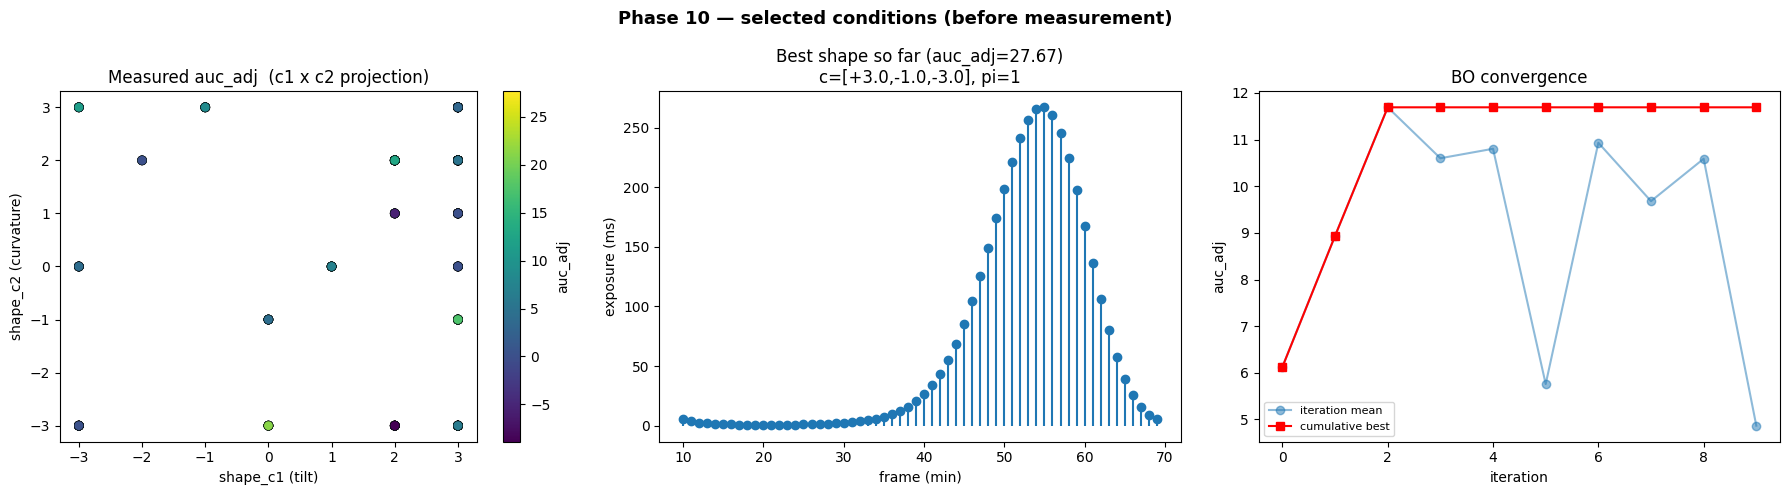

  Cond 0: dropped 33/60 sub-25ms pulses, renormalised to budget
  Cond 1: dropped 13/60 sub-25ms pulses, renormalised to budget
  Cond 2: dropped 15/60 sub-25ms pulses, renormalised to budget
  Created 1620 events for phase 10
    Cond 0 (FOVs 180-185): c=[+3.0,+1.0,-3.0], pulse_interval=1min, n_pulses=60, peak=265ms
    Cond 1 (FOVs 186-191): c=[-2.0,-3.0,-3.0], pulse_interval=1min, n_pulses=60, peak=207ms
    Cond 2 (FOVs 192-197): c=[+2.0,-3.0,+1.0], pulse_interval=1min, n_pulses=60, peak=146ms
  [Level-3] nuisance fit on 1054 cells: slope_baseline=-22.890, slope_logexpr=+1.429, R2=0.153
  Phase 10: 17 FOVs, mean auc_adj=10.734, max=22.337, mean frac_responders=0.49


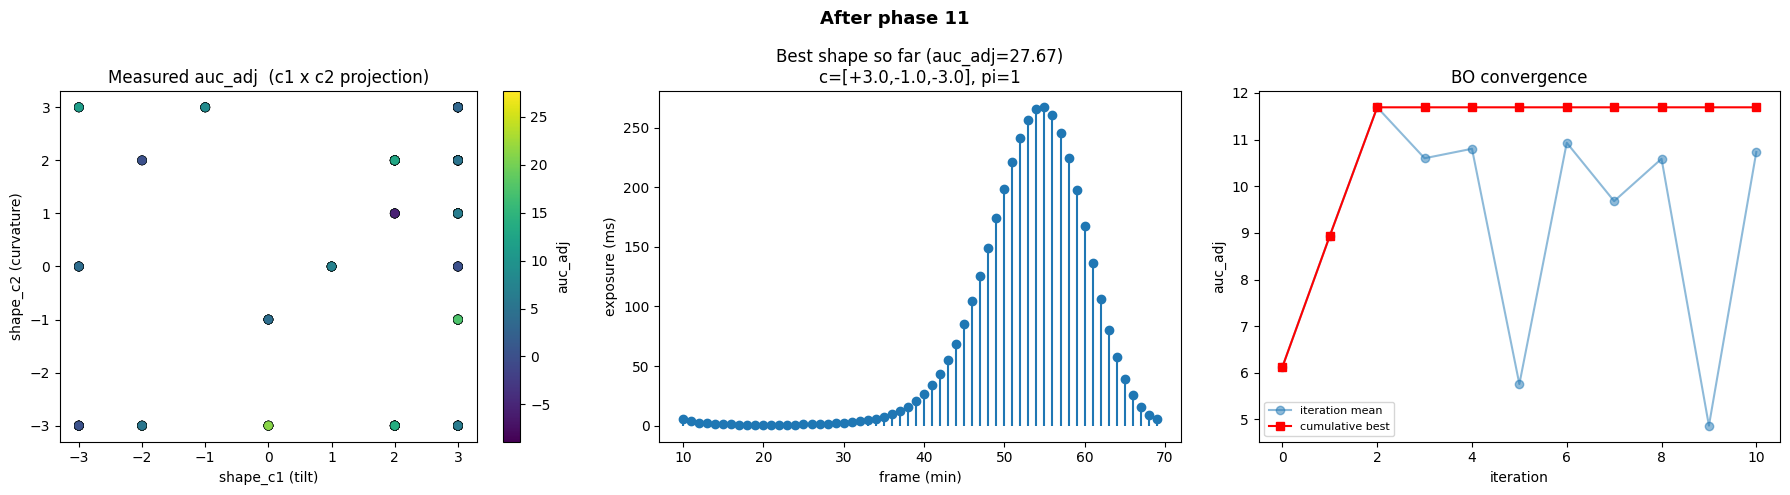


=== ComposedAgent: phase 12/13 ===


C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(


[FOVFinderAgent] Phase 11 — selected FOVs:
    G2_0000: 24 cells (rejected: below_min_cells)
    G2_0001: 19 cells (rejected: below_min_cells)
    G2_0002: 17 cells (rejected: below_min_cells)
    G3_0000: 11 cells (rejected: below_min_cells)
    G3_0001: 9 cells (rejected: below_min_cells)
    G3_0002: 7 cells (rejected: below_min_cells)
    G4_0000: 24 cells (rejected: below_min_cells)
    G4_0001: 9 cells (rejected: below_min_cells)
    G4_0002: 9 cells (rejected: below_min_cells)
    G5_0000: 17 cells (rejected: below_min_cells)
    G5_0001: 15 cells (rejected: below_min_cells)
    G5_0002: 11 cells (rejected: below_min_cells)
    G6_0000: 15 cells (rejected: below_min_cells)
    G6_0001: 8 cells (rejected: below_min_cells)
    G6_0002: 7 cells (rejected: below_min_cells)
    G7_0000: 11 cells (rejected: below_min_cells)
    G7_0001: 10 cells (rejected: below_min_cells)
    G7_0002: 6 cells (rejected: below_min_cells)


sample: 100%|##########| 1200/1200 [00:16<00:00, 71.92it/s, 7 steps of size 6.02e-01. acc. prob=0.89]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      3.91      3.21      3.09      0.28      7.37    827.86      1.00
k_length[1]      4.08      3.78      3.12      0.22      7.85    660.57      1.00
k_length[2]      3.37      2.66      2.66      0.32      6.42    824.07      1.00
k_length[3]      3.16      2.96      2.39      0.22      6.16    715.98      1.00
k_length[4]      1.32      0.82      1.06      0.27      2.54    623.03      1.01
    k_scale      0.43      0.23      0.37      0.14      0.74    644.58      1.00
      noise      0.78      0.10      0.78      0.64      0.94   1421.64      1.00

Computing robust acquisition over 109232 scenarios (6827 grid points x 16 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.160442
  Robust acq stats: min=0.009368, max=0.115238
  [reusing cached GP fit from earlier in this batch]
  [cached predict] reusing predictions for 6826 grid points x 16 covariate samples
 

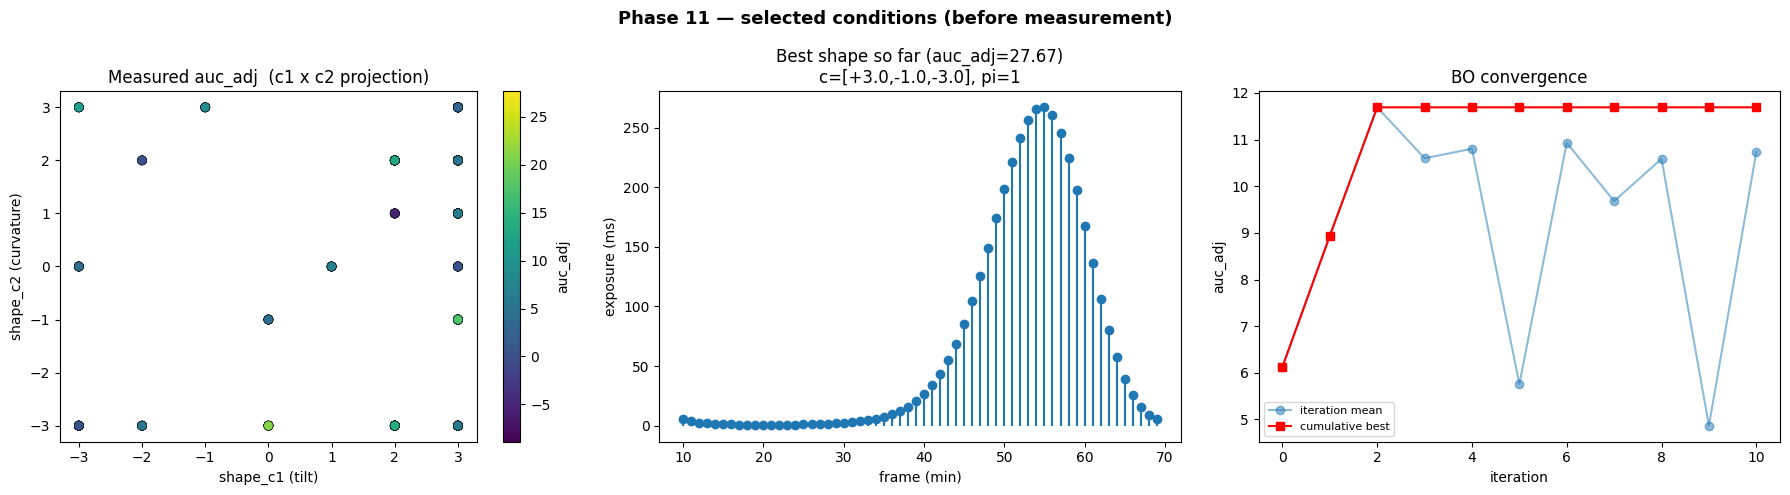

  Cond 0: dropped 1/4 sub-25ms pulses, renormalised to budget
  Cond 1: dropped 26/60 sub-25ms pulses, renormalised to budget
  Created 1620 events for phase 11
    Cond 0 (FOVs 198-203): c=[+3.0,+3.0,-3.0], pulse_interval=16min, n_pulses=4, peak=1842ms
    Cond 1 (FOVs 204-209): c=[+0.0,-2.0,-3.0], pulse_interval=1min, n_pulses=60, peak=212ms
    Cond 2 (FOVs 210-215): c=[+3.0,+0.0,-3.0], pulse_interval=16min, n_pulses=4, peak=3256ms
  [Level-3] nuisance fit on 1149 cells: slope_baseline=-21.305, slope_logexpr=+1.650, R2=0.142
  Phase 11: 17 FOVs, mean auc_adj=8.275, max=15.134, mean frac_responders=0.41


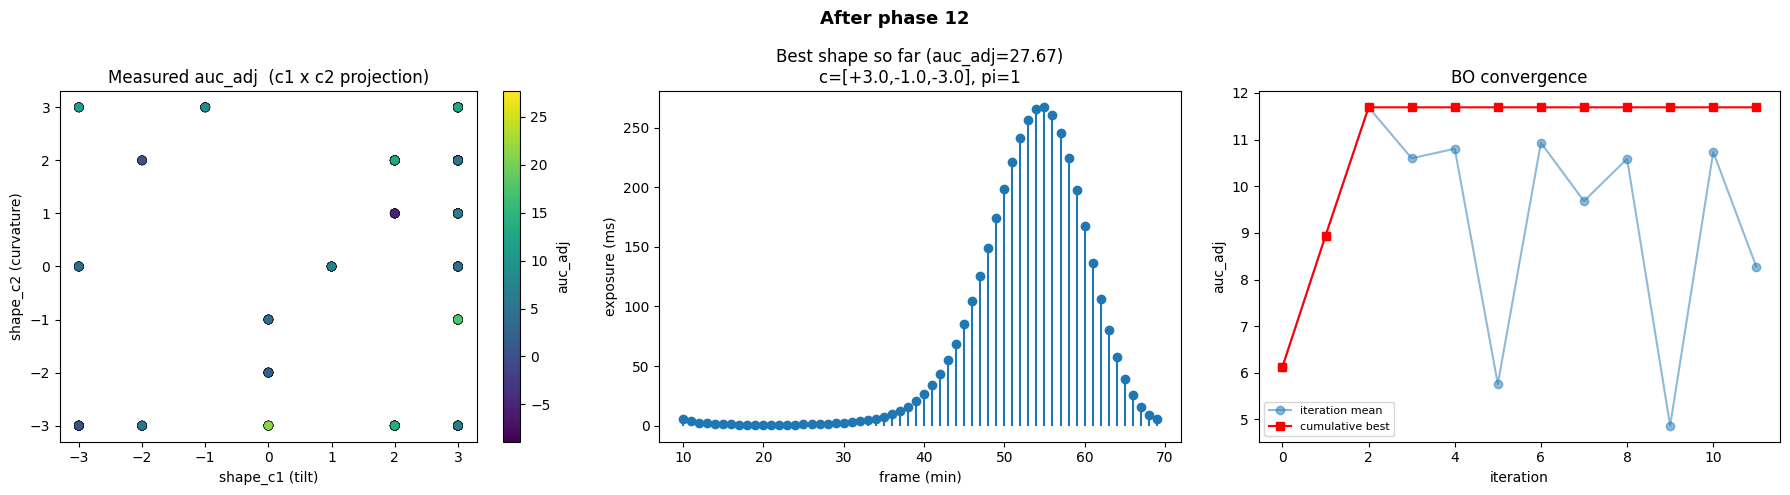


=== ComposedAgent: phase 13/13 ===


no seeds found in get_masks_torch - no masks found.
C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(


[FOVFinderAgent] Phase 12 — selected FOVs:
    G8_0000: 23 cells (rejected: below_min_cells)
    G8_0001: 14 cells (rejected: below_min_cells)
    G8_0002: 7 cells (rejected: below_min_cells)
    G9_0000: 5 cells (rejected: below_min_cells)
    G9_0001: 4 cells (rejected: below_min_cells)
    G9_0002: 4 cells (rejected: below_min_cells)
    G10_0000: 8 cells (rejected: below_min_cells)
    G10_0001: 6 cells (rejected: below_min_cells)
    G10_0002: 6 cells (rejected: below_min_cells)
    G11_0000: 11 cells (rejected: below_min_cells)
    G11_0001: 9 cells (rejected: below_min_cells)
    G11_0002: 6 cells (rejected: below_min_cells)
    G12_0000: 7 cells (rejected: below_min_cells)
    G12_0001: 4 cells (rejected: below_min_cells)
    G12_0002: 3 cells (rejected: below_min_cells)
    H12_0000: 5 cells (rejected: below_min_cells)
    H12_0001: 4 cells (rejected: below_min_cells)
    H12_0002: 4 cells (rejected: below_min_cells)


sample: 100%|##########| 1200/1200 [00:20<00:00, 59.94it/s, 7 steps of size 6.07e-01. acc. prob=0.89]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      3.82      3.02      3.06      0.51      7.35    780.57      1.00
k_length[1]      4.36      3.85      3.31      0.28      8.59    701.59      1.00
k_length[2]      3.71      3.02      2.84      0.44      7.44    798.16      1.00
k_length[3]      3.55      3.20      2.68      0.22      7.26    634.68      1.00
k_length[4]      1.45      0.90      1.19      0.29      2.65    530.80      1.00
    k_scale      0.42      0.22      0.37      0.14      0.73    853.11      1.00
      noise      0.80      0.09      0.79      0.66      0.94    940.78      1.00

Computing robust acquisition over 109184 scenarios (6824 grid points x 16 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.197502
  Robust acq stats: min=0.029928, max=0.162594
  [reusing cached GP fit from earlier in this batch]
  [cached predict] reusing predictions for 6823 grid points x 16 covariate samples
 

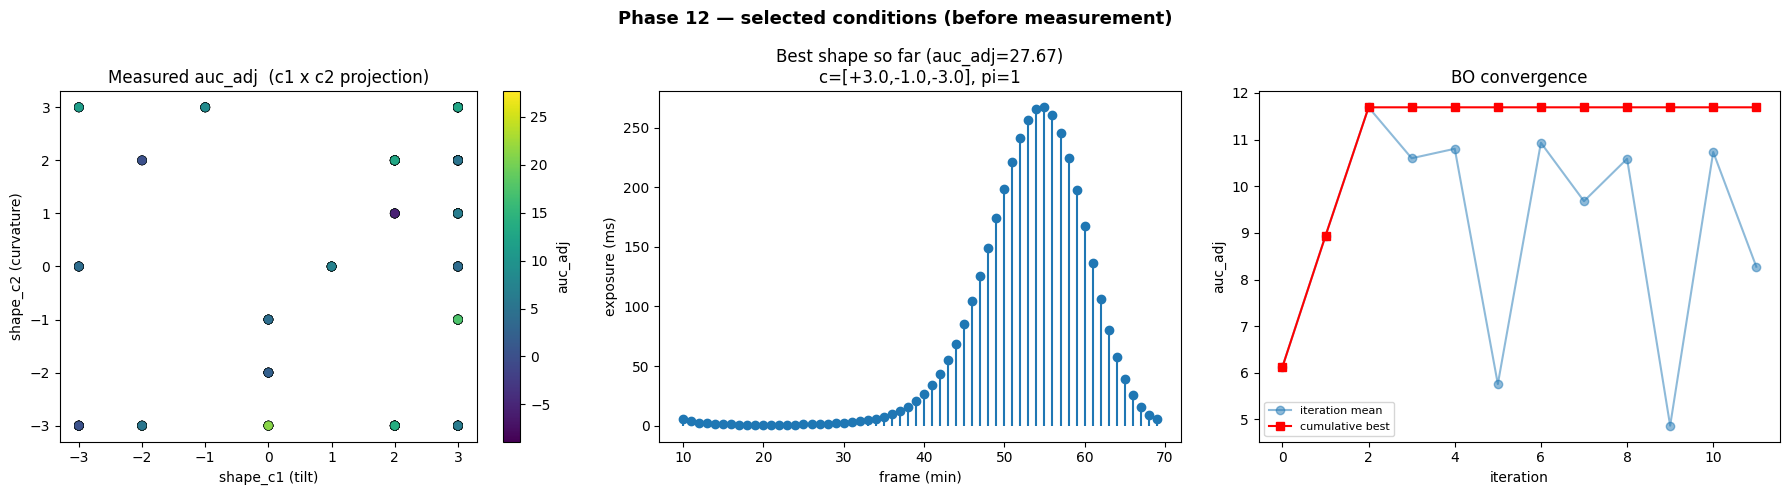

  Cond 0: dropped 36/60 sub-25ms pulses, renormalised to budget
  Cond 1: dropped 28/60 sub-25ms pulses, renormalised to budget
  Cond 2: dropped 48/60 sub-25ms pulses, renormalised to budget
  Created 1620 events for phase 12
    Cond 0 (FOVs 216-221): c=[+3.0,+3.0,-3.0], pulse_interval=1min, n_pulses=60, peak=284ms
    Cond 1 (FOVs 222-227): c=[+1.0,+2.0,-1.0], pulse_interval=1min, n_pulses=60, peak=252ms
    Cond 2 (FOVs 228-233): c=[+3.0,+3.0,+0.0], pulse_interval=1min, n_pulses=60, peak=1246ms
  [Level-3] nuisance fit on 1206 cells: slope_baseline=-21.432, slope_logexpr=+1.462, R2=0.143
  Phase 12: 17 FOVs, mean auc_adj=5.883, max=23.042, mean frac_responders=0.26


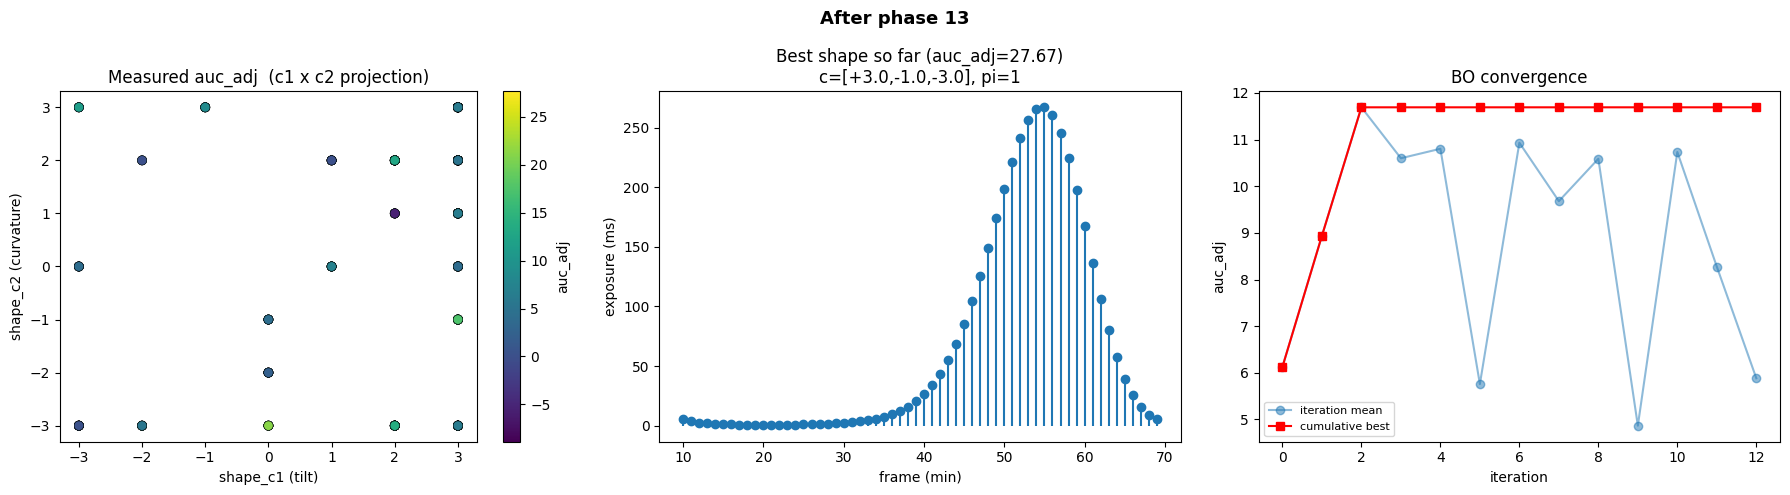

In [17]:
# --- v13 phase-0 gate: starvation monitor on the sacrificial well ----------
# Replaces the old fixed "sleep until morning" wait.  The monitor images
# WELLS[0] every 20 min and returns once 75 % of cells have CNR < 1.0
# (cells starved down) or after a 20 h timeout.

# Disconnect napari live view so it does not interfere with the engine.
try:
    mm_wdg._core_link.cleanup()
except Exception:
    pass


# --- Run the composed (FOV finder + BO) loop on the fresh wells ------------
# Each phase: FOVFinder picks 18 FOVs in 6 fresh wells (from WELLS[1:]),
# then BudgetOscillationBO runs one batch BO iteration over them.  The GP
# accumulates observations across all phases.
composed_agent.run()

In [18]:
# Post-processing: merge per-FOV tracks
utils.generate_exp_data_from_tracks(path)

## Visualise results

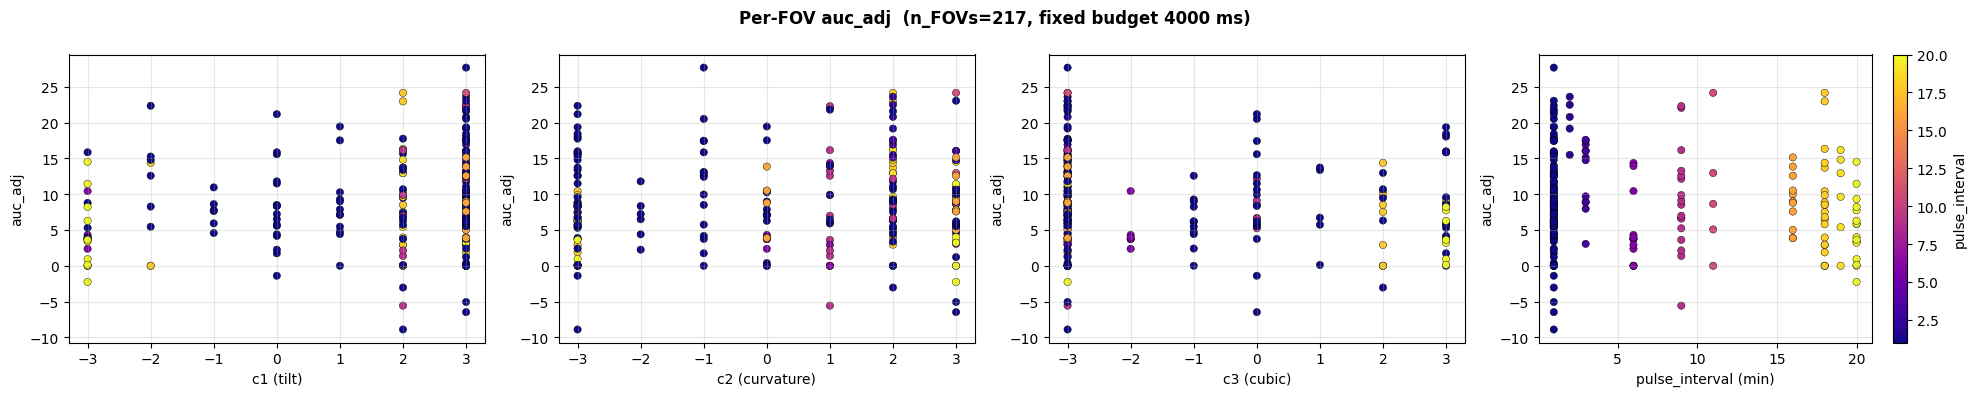

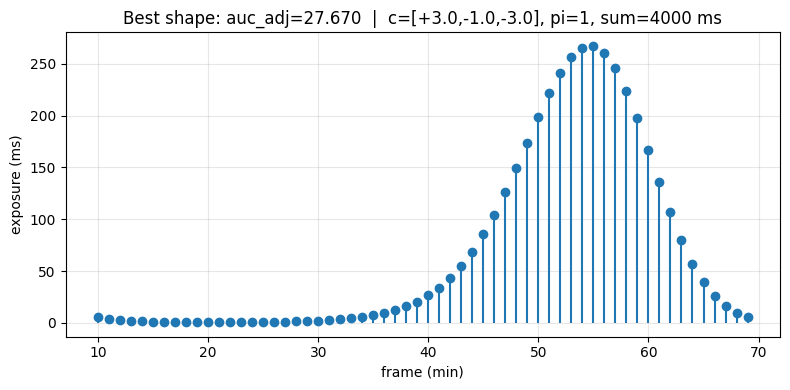

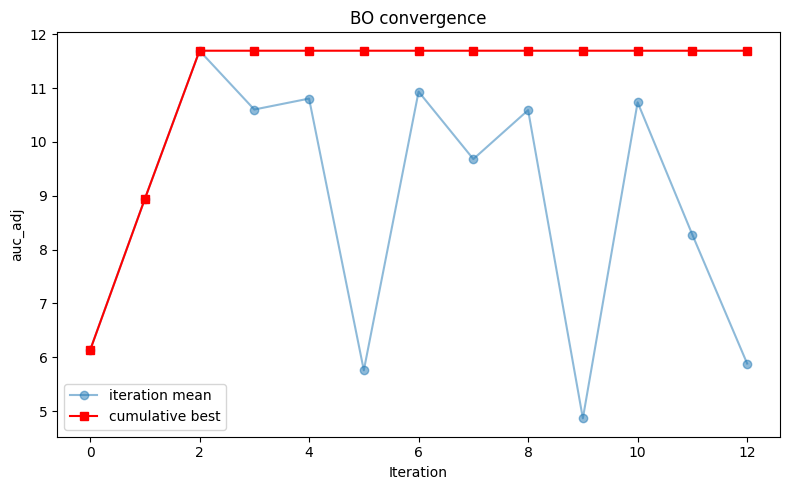


Best condition by auc_adj (mean across FOVs):
  shape_c1 (tilt)      = +3.00
  shape_c2 (curvature) = +2.00
  shape_c3 (cubic)     = -3.00
  pulse_interval       = 2 min
  -> mean peak pulse   = 547.4 ms
  mean auc_adj      = 20.3014
  mean auc_above_base  = 17.3567
  tested on 5 FOVs


In [19]:
# --- v14 results: measured auc_norm over the 4-D free-shape space ---
if agent.df_results is not None and not agent.df_results.empty:
    df = agent.df_results
    obj_name = agent.objective_metric.name

    # Per-FOV objective vs each BO axis (4 projections of the 4-D space).
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for ax, col, lbl in zip(
        axes,
        ["shape_c1", "shape_c2", "shape_c3", "pulse_interval"],
        ["c1 (tilt)", "c2 (curvature)", "c3 (cubic)", "pulse_interval (min)"],
    ):
        sc = ax.scatter(
            df[col],
            df[obj_name],
            c=df["pulse_interval"],
            cmap="plasma",
            s=28,
            edgecolors="k",
            linewidths=0.3,
        )
        ax.set_xlabel(lbl)
        ax.set_ylabel(obj_name)
        ax.grid(alpha=0.3)
    fig.colorbar(sc, ax=axes[-1], label="pulse_interval")
    fig.suptitle(
        f"Per-FOV {obj_name}  (n_FOVs={len(df)}, fixed budget "
        f"{FIXED_LIGHT_BUDGET_MS:.0f} ms)",
        fontsize=12,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

    # Render the best shape found.
    best = df.loc[df[obj_name].idxmax()]
    pi = max(1, int(best["pulse_interval"]))
    coeffs = [best["shape_c1"], best["shape_c2"], best["shape_c3"]]
    frames = pulse_positions(pi, FIRST_FRAME_STIM, LAST_FRAME_STIM)
    expo = shape_exposures(coeffs, len(frames), FIXED_LIGHT_BUDGET_MS)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.stem(frames, expo, basefmt=" ")
    ax.set_xlabel("frame (min)")
    ax.set_ylabel("exposure (ms)")
    ax.set_title(
        f"Best shape: {obj_name}={best[obj_name]:.3f}  |  "
        f"c=[{coeffs[0]:+.1f},{coeffs[1]:+.1f},{coeffs[2]:+.1f}], pi={pi}, "
        f"sum={expo.sum():.0f} ms"
    )
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Convergence.
    if agent._iteration_means:
        fig, ax = plt.subplots(figsize=(8, 5))
        means = np.array(agent._iteration_means)
        ax.plot(means, "o-", alpha=0.5, label="iteration mean")
        ax.plot(
            np.maximum.accumulate(means), "s-", color="red", label="cumulative best"
        )
        ax.set_xlabel("Iteration")
        ax.set_ylabel(obj_name)
        ax.set_title("BO convergence")
        ax.legend()
        plt.tight_layout()
        plt.show()

    # Best condition by the configured BO objective.
    cond_all = (
        df.groupby(["shape_c1", "shape_c2", "shape_c3", "pulse_interval"])
        .agg(
            mean_obj=(obj_name, "mean"),
            mean_auc=("auc_above_baseline", "mean"),
            n_fovs=(obj_name, "count"),
            mean_peak=("peak_exposure", "mean"),
        )
        .reset_index()
    )
    best = cond_all.loc[cond_all["mean_obj"].idxmax()]
    print(f"\nBest condition by {obj_name} (mean across FOVs):")
    print(f"  shape_c1 (tilt)      = {best['shape_c1']:+.2f}")
    print(f"  shape_c2 (curvature) = {best['shape_c2']:+.2f}")
    print(f"  shape_c3 (cubic)     = {best['shape_c3']:+.2f}")
    print(f"  pulse_interval       = {int(best['pulse_interval'])} min")
    print(f"  -> mean peak pulse   = {best['mean_peak']:.1f} ms")
    print(f"  mean {obj_name}      = {best['mean_obj']:.4f}")
    print(f"  mean auc_above_base  = {best['mean_auc']:.4f}")
    print(f"  tested on {int(best['n_fovs'])} FOVs")
else:
    print("No data collected yet.")

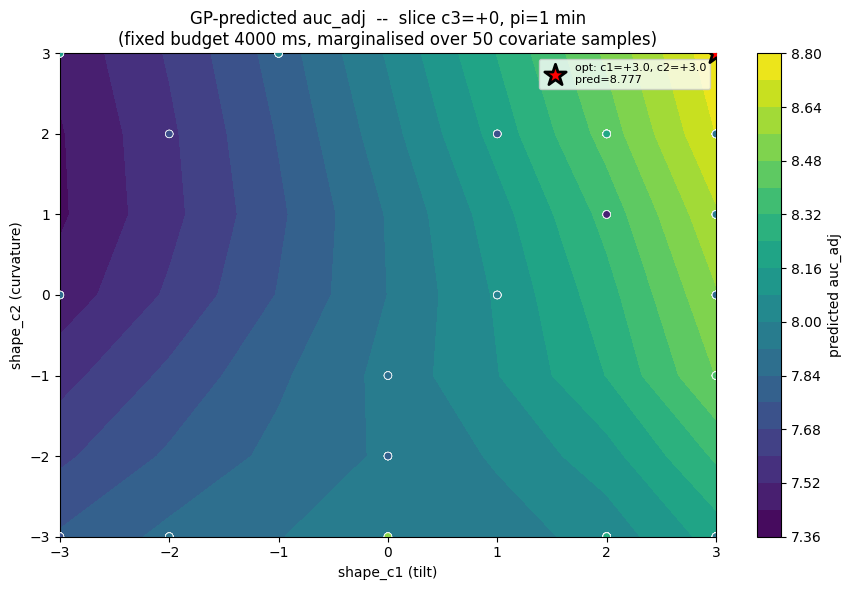

GP-predicted optimum in this slice: shape_c1=+3.00, shape_c2=+3.00 (c3=+0, pi=1), predicted auc_adj=8.7771


In [20]:
# GP-predicted landscape SLICE: shape_c1 x shape_c2 at c3=0 and the best
# observed pulse_interval, marginalised over covariates the SAME way the BO
# acquisition does (average GP predictions over empirical covariate samples).
import gpax
import gpax.utils
from faro.agents.bo_optimization_sparse import _safe_batch_size

if agent.model is not None and agent.x is not None:
    obj_name = agent.objective_metric.name
    rng_key, rng_key_pred = gpax.utils.get_keys()

    # Control grid axes (columns of x_total_linespace): 0=c1,1=c2,2=c3,3=pi.
    c1_vals = np.unique(agent.x_total_linespace[:, 0])
    c2_vals = np.unique(agent.x_total_linespace[:, 1])
    c3_vals = np.unique(agent.x_total_linespace[:, 2])
    pi_vals = np.unique(agent.x_total_linespace[:, 3])
    n_1, n_2 = len(c1_vals), len(c2_vals)

    df = agent.df_results
    # Slice fixed at c3 nearest 0 and the best observed pulse_interval.
    c3_fix = float(c3_vals[np.argmin(np.abs(c3_vals))])
    best_pi = int(df.loc[df[obj_name].idxmax(), "pulse_interval"])
    pi_fix = float(pi_vals[np.argmin(np.abs(pi_vals - best_pi))])

    n_cov_samples = 50
    cov_vals_full = df[[c.name for c in agent.bo_covariates]].to_numpy(dtype=float)
    if cov_vals_full.shape[0] == 0:
        raise RuntimeError("No covariate observations available for marginalisation.")
    _rng = np.random.default_rng(0)
    cov_samples = cov_vals_full[_rng.integers(0, cov_vals_full.shape[0], n_cov_samples)]

    ctrl_grid = np.array([[a, b, c3_fix, pi_fix] for a in c1_vals for b in c2_vals])
    n_grid = ctrl_grid.shape[0]
    x_full = np.hstack(
        [
            np.repeat(ctrl_grid, n_cov_samples, axis=0),
            np.tile(cov_samples, (n_grid, 1)),
        ]
    )
    x_full_scaled = agent._x_scaler.transform(x_full)

    bs = _safe_batch_size(np.asarray(x_full_scaled).shape[0], 2000)
    y_pred_scaled, _ = agent.model.predict_in_batches(
        rng_key_pred,
        x_full_scaled,
        batch_size=bs,
        n=1,
        noiseless=True,
    )
    y_pred = agent._y_scaler.inverse_transform(
        np.asarray(y_pred_scaled).reshape(-1, 1)
    ).flatten()
    Y = y_pred.reshape(n_grid, n_cov_samples).mean(axis=1).reshape(n_1, n_2)

    flat = int(np.argmax(Y))
    i1, i2 = np.unravel_index(flat, (n_1, n_2))
    opt_c1, opt_c2, opt_val = c1_vals[i1], c2_vals[i2], Y[i1, i2]

    fig, ax = plt.subplots(figsize=(9, 6))
    cf = ax.contourf(c1_vals, c2_vals, Y.T, levels=20, cmap="viridis")
    fig.colorbar(cf, ax=ax, label=f"predicted {obj_name}")
    ax.scatter(
        df["shape_c1"],
        df["shape_c2"],
        c=df[obj_name],
        cmap="viridis",
        s=30,
        edgecolors="white",
        linewidths=0.5,
        zorder=5,
    )
    ax.scatter(
        opt_c1,
        opt_c2,
        c="red",
        s=260,
        marker="*",
        edgecolors="black",
        linewidths=2,
        zorder=10,
        label=f"opt: c1={opt_c1:+.1f}, c2={opt_c2:+.1f}\npred={opt_val:.3f}",
    )
    ax.set_xlabel("shape_c1 (tilt)")
    ax.set_ylabel("shape_c2 (curvature)")
    ax.set_title(
        f"GP-predicted {obj_name}  --  slice c3={c3_fix:+.0f}, pi={int(pi_fix)} min\n"
        f"(fixed budget {FIXED_LIGHT_BUDGET_MS:.0f} ms, marginalised over "
        f"{n_cov_samples} covariate samples)"
    )
    ax.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()

    print(
        f"GP-predicted optimum in this slice: shape_c1={opt_c1:+.2f}, "
        f"shape_c2={opt_c2:+.2f} (c3={c3_fix:+.0f}, pi={int(pi_fix)}), "
        f"predicted {obj_name}={opt_val:.4f}"
    )
else:
    print("GP not fit yet -- run the BO first.")

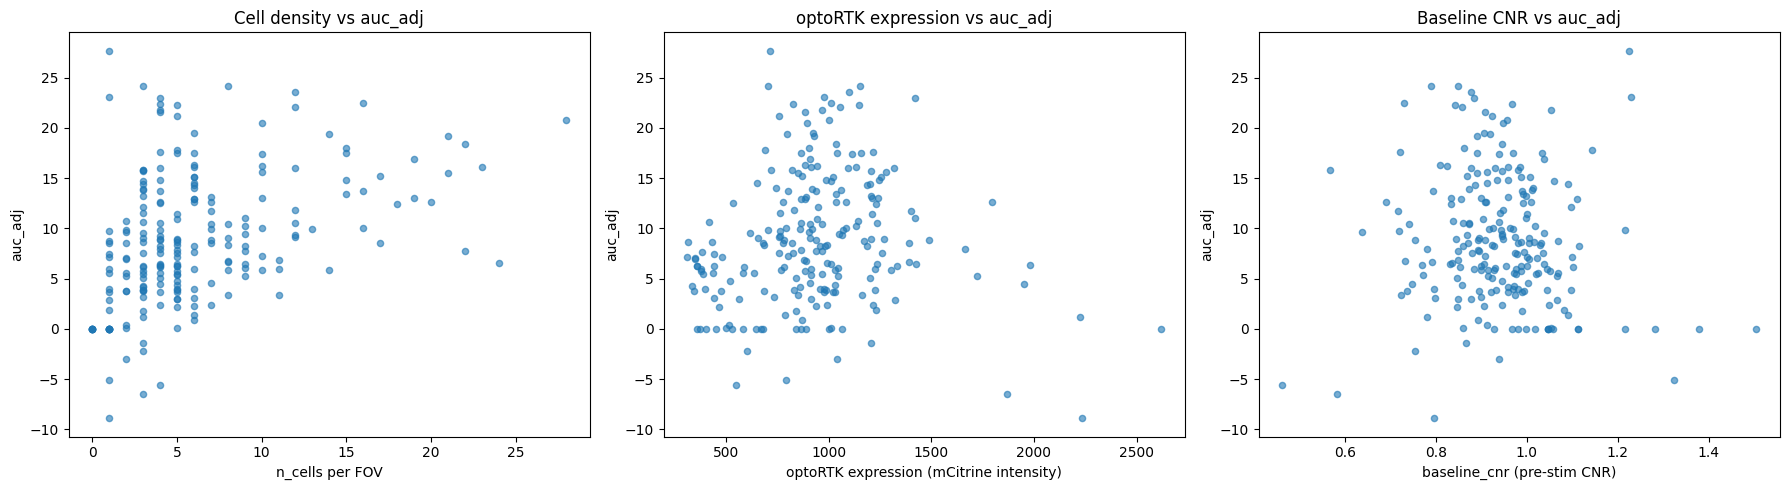

In [21]:
# Covariate effects on the configured BO objective (per FOV)
if agent.df_results is not None and not agent.df_results.empty:
    df = agent.df_results
    obj_name = agent.objective_metric.name

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].scatter(df["n_cells"], df[obj_name], alpha=0.6, s=20)
    axes[0].set_xlabel("n_cells per FOV")
    axes[0].set_ylabel(obj_name)
    axes[0].set_title(f"Cell density vs {obj_name}")

    axes[1].scatter(df["optortk_expression"], df[obj_name], alpha=0.6, s=20)
    axes[1].set_xlabel("optoRTK expression (mCitrine intensity)")
    axes[1].set_ylabel(obj_name)
    axes[1].set_title(f"optoRTK expression vs {obj_name}")

    axes[2].scatter(df["baseline_cnr"], df[obj_name], alpha=0.6, s=20)
    axes[2].set_xlabel("baseline_cnr (pre-stim CNR)")
    axes[2].set_ylabel(obj_name)
    axes[2].set_title(f"Baseline CNR vs {obj_name}")

    plt.tight_layout()
    plt.show()

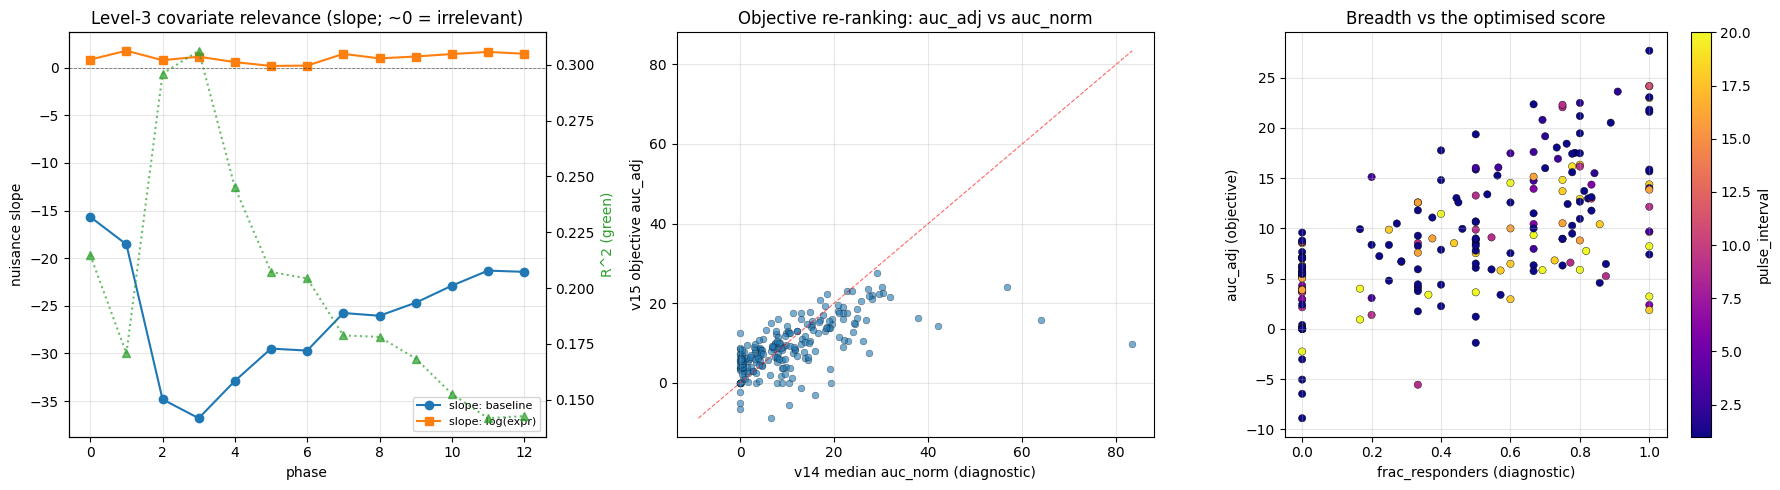

Nuisance fit history (per phase):
 phase_id  a_baseline  b_logexpr       r2  n_cells_cum
        0  -15.664224   0.848723 0.214788           64
        1  -18.547843   1.779365 0.170704          104
        2  -34.818256   0.779550 0.295994          265
        3  -36.797328   1.150526 0.306310          350
        4  -32.883241   0.583881 0.245053          465
        5  -29.490649   0.179229 0.207189          510
        6  -29.698604   0.215698 0.204311          678
        7  -25.754653   1.447239 0.178762          775
        8  -26.042885   0.973336 0.178115          859
        9  -24.674184   1.170093 0.168407          899
       10  -22.890066   1.429289 0.152584         1054
       11  -21.305120   1.650483 0.141694         1149
       12  -21.432100   1.462073 0.142637         1206


In [22]:
# --- v15 Level-3 diagnostics: did the cell-level adjustment matter? ---------
# (1) nuisance slopes + R^2 across phases (relevance readout that REPLACES ARD
#     for the covariates);  (2) auc_adj vs the v14 median auc_norm (did the
#     objective re-rank conditions?);  (3) frac_responders vs auc_adj.
if getattr(agent, "_nuisance_history", None):
    hist = pd.DataFrame(agent._nuisance_history)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    ax = axes[0]
    ax.plot(hist["phase_id"], hist["a_baseline"], "o-", label="slope: baseline")
    ax.plot(hist["phase_id"], hist["b_logexpr"], "s-", label="slope: log(expr)")
    ax.axhline(0.0, color="k", lw=0.6, ls="--", alpha=0.5)
    ax.set_xlabel("phase")
    ax.set_ylabel("nuisance slope")
    ax.set_title("Level-3 covariate relevance (slope; ~0 = irrelevant)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax2 = ax.twinx()
    ax2.plot(hist["phase_id"], hist["r2"], "^:", color="tab:green", alpha=0.7)
    ax2.set_ylabel("R^2 (green)", color="tab:green")

    if agent.df_results is not None and not agent.df_results.empty:
        df = agent.df_results
        ax = axes[1]
        ax.scatter(
            df["auc_norm"],
            df["auc_adj"],
            s=24,
            alpha=0.6,
            edgecolors="k",
            linewidths=0.3,
        )
        lim = [
            min(df["auc_norm"].min(), df["auc_adj"].min()),
            max(df["auc_norm"].max(), df["auc_adj"].max()),
        ]
        ax.plot(lim, lim, "r--", lw=0.8, alpha=0.6)
        ax.set_xlabel("v14 median auc_norm (diagnostic)")
        ax.set_ylabel("v15 objective auc_adj")
        ax.set_title("Objective re-ranking: auc_adj vs auc_norm")
        ax.grid(alpha=0.3)

        ax = axes[2]
        sc = ax.scatter(
            df["frac_responders"],
            df["auc_adj"],
            c=df["pulse_interval"],
            cmap="plasma",
            s=28,
            edgecolors="k",
            linewidths=0.3,
        )
        fig.colorbar(sc, ax=ax, label="pulse_interval")
        ax.set_xlabel("frac_responders (diagnostic)")
        ax.set_ylabel("auc_adj (objective)")
        ax.set_title("Breadth vs the optimised score")
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("Nuisance fit history (per phase):")
    print(hist.to_string(index=False))
else:
    print("No nuisance history yet -- run the BO first.")

In [23]:
import pandas as pd
import glob, os

# Per-phase delta of conditions tested, in BO-axis terms
# (shape_c1/c2/c3, pulse_interval).  light_budget is pinned so not shown.
RUN_PATH = path
ckpts = sorted(
    glob.glob(os.path.join(RUN_PATH, "checkpoints", "bo_results_phase_*.parquet"))
)

prev_len = 0
for f in ckpts:
    phase_id = int(os.path.basename(f).split("_")[-1].split(".")[0])
    df = pd.read_parquet(f)
    df_new = df.iloc[prev_len:]
    prev_len = len(df)
    conds = (
        df_new[["shape_c1", "shape_c2", "shape_c3", "pulse_interval"]]
        .drop_duplicates()
        .values.tolist()
    )
    cond_str = "  |  ".join(
        f"(c=[{c1:+.1f},{c2:+.1f},{c3:+.1f}], pi={int(p)})" for c1, c2, c3, p in conds
    )
    print(f"Phase {phase_id:2d}  ({len(df_new):2d} FOVs): {cond_str}")

Phase  0  (17 FOVs): (c=[-3.0,+0.0,-2.0], pi=6)  |  (c=[+2.0,-3.0,+2.0], pi=18)  |  (c=[+2.0,+2.0,+2.0], pi=1)
Phase  1  (15 FOVs): (c=[+2.0,+2.0,-3.0], pi=18)  |  (c=[+2.0,-3.0,-3.0], pi=1)  |  (c=[-2.0,+2.0,+2.0], pi=18)
Phase  2  (17 FOVs): (c=[+2.0,+2.0,-3.0], pi=19)  |  (c=[+3.0,-3.0,-3.0], pi=18)  |  (c=[+3.0,+2.0,-3.0], pi=2)
Phase  3  (17 FOVs): (c=[+3.0,+2.0,-3.0], pi=3)  |  (c=[-1.0,+3.0,-3.0], pi=1)  |  (c=[+3.0,+3.0,-3.0], pi=11)
Phase  4  (17 FOVs): (c=[+3.0,+2.0,-3.0], pi=1)  |  (c=[+3.0,+2.0,+0.0], pi=9)  |  (c=[+3.0,+1.0,-3.0], pi=9)
Phase  5  (16 FOVs): (c=[+3.0,+1.0,-3.0], pi=6)  |  (c=[-3.0,-3.0,+3.0], pi=1)  |  (c=[-3.0,+3.0,-3.0], pi=20)
Phase  6  (17 FOVs): (c=[+3.0,+3.0,-3.0], pi=3)  |  (c=[+3.0,+3.0,+3.0], pi=20)  |  (c=[+3.0,-3.0,+3.0], pi=1)
Phase  7  (17 FOVs): (c=[+2.0,+1.0,-3.0], pi=9)  |  (c=[+1.0,+0.0,-3.0], pi=1)  |  (c=[+3.0,-1.0,+0.0], pi=1)
Phase  8  (17 FOVs): (c=[+3.0,-1.0,-3.0], pi=1)  |  (c=[+0.0,-3.0,+0.0], pi=1)  |  (c=[+3.0,-3.0,-1.0], pi=1)
Ph

In [24]:
# --- v13 stopping-criterion diagnostic (PRINTED, not enforced) -------------
# A practical convergence check: after each phase, look at the cumulative-best
# objective.  We FLAG the phase where the BO would have been stopped, but the
# run is NOT halted -- this is a diagnostic for the midterm, to show how many
# phases added little.
if agent.df_results is not None and agent._iteration_means:
    means = np.array(agent._iteration_means)
    cum_best = np.maximum.accumulate(means)

    REL_TOL = 0.02  # < 2 % improvement in cumulative best ...
    PATIENCE = 3  # ... for 3 consecutive phases => "converged"

    stalled = 0
    stop_phase = None
    print("Phase | iter-mean | cum-best | d(cum-best) | status")
    print("-" * 58)
    for i in range(len(means)):
        if i == 0:
            delta = float("nan")
        else:
            denom = abs(cum_best[i - 1]) if cum_best[i - 1] != 0 else 1.0
            delta = (cum_best[i] - cum_best[i - 1]) / denom
            stalled = stalled + 1 if delta < REL_TOL else 0
        flag = ""
        if stop_phase is None and stalled >= PATIENCE:
            stop_phase = i
            flag = "  <-- would STOP here"
        print(
            f"{i:5d} | {means[i]:9.4f} | {cum_best[i]:8.4f} | "
            f"{delta:11.4f} | {flag}"
        )

    if stop_phase is not None:
        wasted = len(means) - 1 - stop_phase
        print(
            f"\nStopping criterion: cumulative best improved < {REL_TOL:.0%} "
            f"for {PATIENCE} consecutive phases at phase {stop_phase}. "
            f"{wasted} later phase(s) (~{wasted * N_FOVS} FOVs) added little "
            f"-- NOT enforced."
        )
    else:
        print(
            f"\nStopping criterion never met: the BO was still improving at "
            f"the last phase (no plateau of {PATIENCE} phases)."
        )
else:
    print("No iteration history yet -- run the BO first.")

Phase | iter-mean | cum-best | d(cum-best) | status
----------------------------------------------------------
    0 |    6.1262 |   6.1262 |         nan | 
    1 |    8.9374 |   8.9374 |      0.4589 | 
    2 |   11.6929 |  11.6929 |      0.3083 | 
    3 |   10.6007 |  11.6929 |      0.0000 | 
    4 |   10.8040 |  11.6929 |      0.0000 | 
    5 |    5.7578 |  11.6929 |      0.0000 |   <-- would STOP here
    6 |   10.9327 |  11.6929 |      0.0000 | 
    7 |    9.6806 |  11.6929 |      0.0000 | 
    8 |   10.5893 |  11.6929 |      0.0000 | 
    9 |    4.8656 |  11.6929 |      0.0000 | 
   10 |   10.7343 |  11.6929 |      0.0000 | 
   11 |    8.2748 |  11.6929 |      0.0000 | 
   12 |    5.8832 |  11.6929 |      0.0000 | 

Stopping criterion: cumulative best improved < 2% for 3 consecutive phases at phase 5. 7 later phase(s) (~126 FOVs) added little -- NOT enforced.
